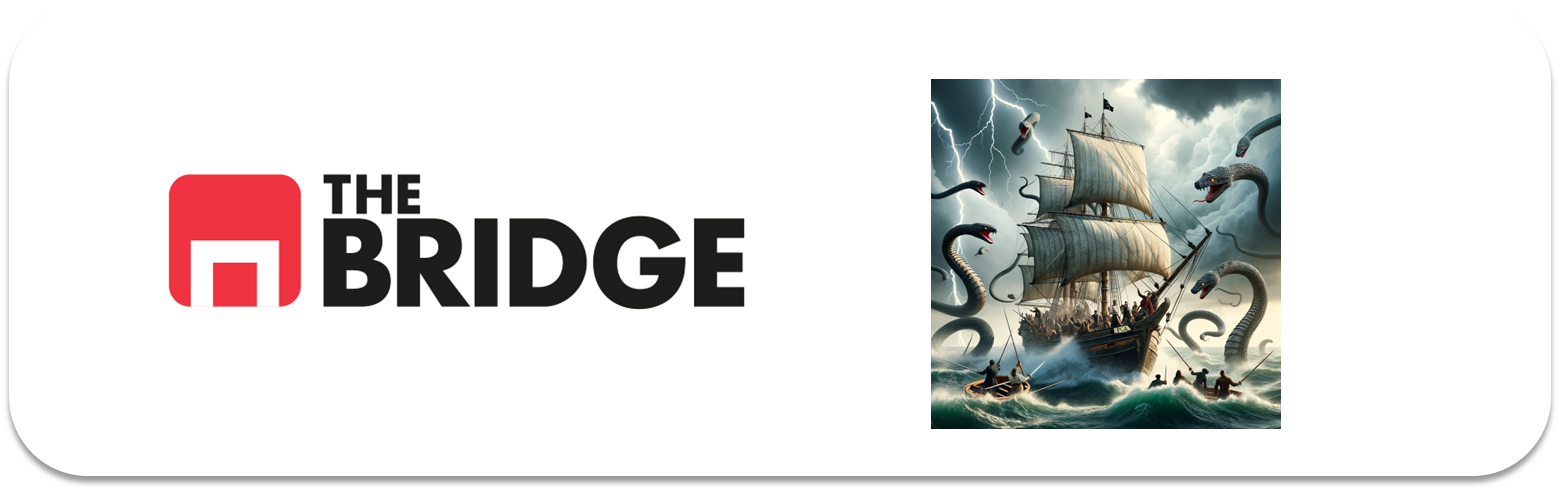

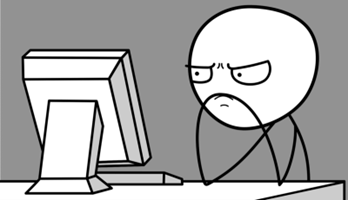

Para ejercitarte y afianzar lo aprendido sobre **Seleccion de Features**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

## Feature selection: Breast Cancer Winsconsin

El objetivo de este grupo de ejercicio es dar a entender la importancia de la selección de características (features), así como probar distintos métodos de reducción de características (features) y qué influencia puede tener el reducir features en el perfomance de un modelo. Nuestro target para evaluar el perfomance será si estamos ante tumores malignos o benignos.

Vamos a trabajar con el dataset de Breast Cancer Winsconsin, datos tomados a partir de radiografías.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import bootcampviztools as bt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import toolbox_ML as tool


# Control de warnings
pd.options.mode.copy_on_write = True # CoW por defecto a partir de pandas 3.0.0

### Ejercicio 1:

Carga los datos y haz una primera inspección de los mismos y comenta lo que creas conveniente sobre las features y su relación entre sí (pero sin analizarlas numéricamente)

In [2]:
df = pd.read_csv("./data/breastcancer-winsconsin.csv",index_col="id")
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 842302 to 92751
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                 

In [4]:
print(tool.describe_df(df))

                          data_type valores_nulos valores_unicos  \
diagnosis                categorica           0.0              2   
radius_mean                numerica           0.0            456   
texture_mean               numerica           0.0            479   
perimeter_mean             numerica           0.0            522   
area_mean                  numerica           0.0            539   
smoothness_mean            numerica           0.0            474   
compactness_mean           numerica           0.0            537   
concavity_mean             numerica           0.0            537   
concave points_mean        numerica           0.0            542   
symmetry_mean              numerica           0.0            432   
fractal_dimension_mean     numerica           0.0            499   
radius_se                  numerica           0.0            540   
texture_se                 numerica           0.0            519   
perimeter_se               numerica           0.

In [5]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [6]:
target = "diagnosis"
col_num_mean =['radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       ]
col_num_se =['radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se']
col_num_worst = ['radius_worst', 'texture_worst','perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst']


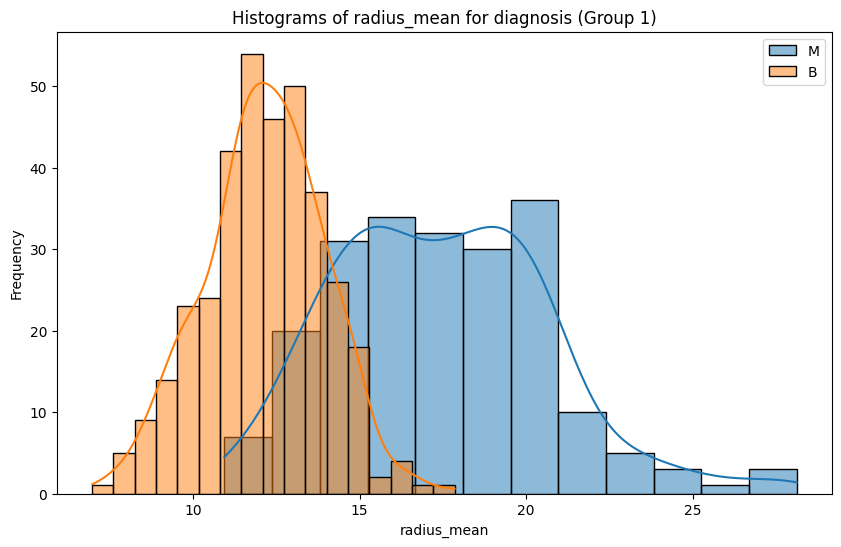

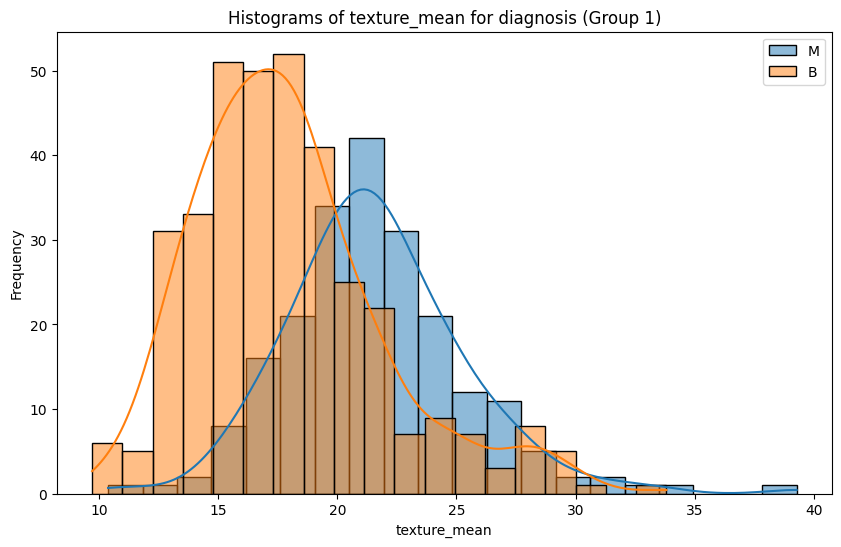

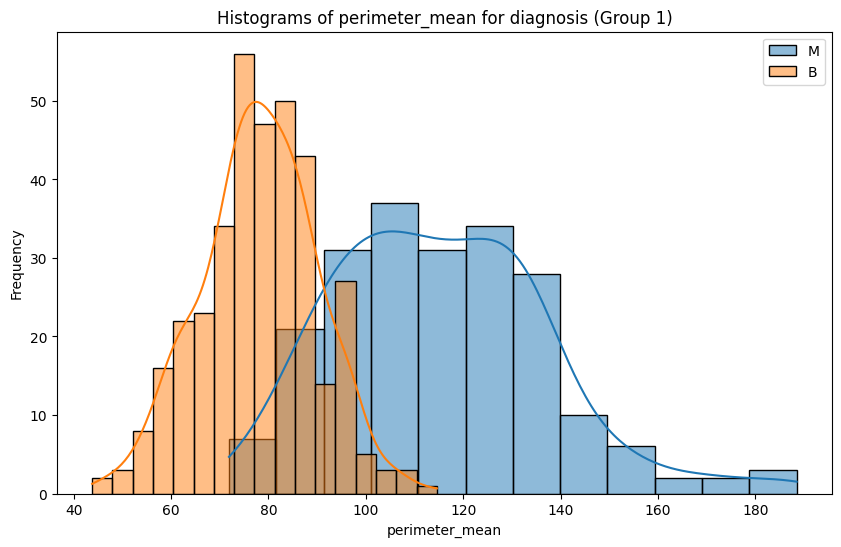

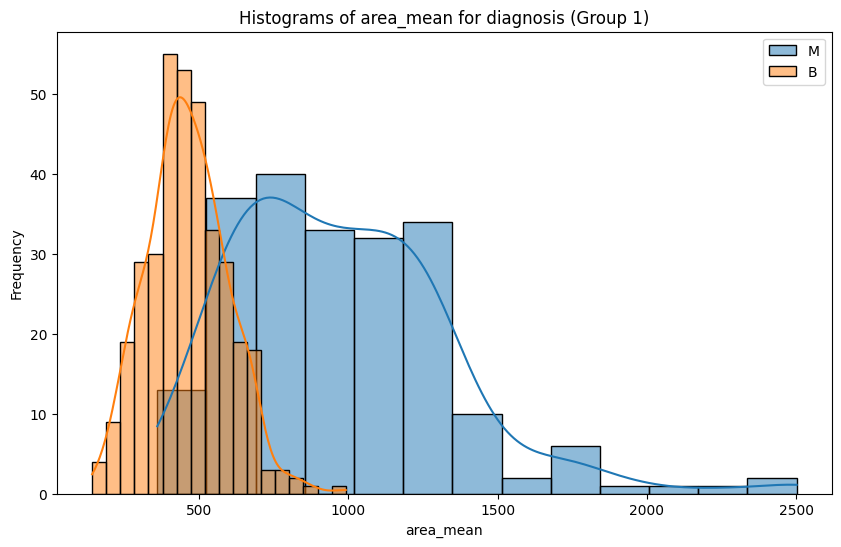

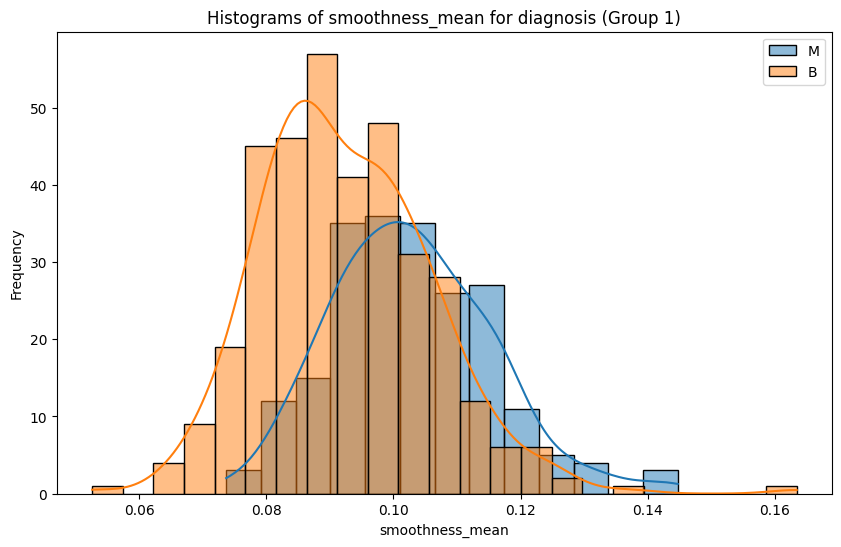

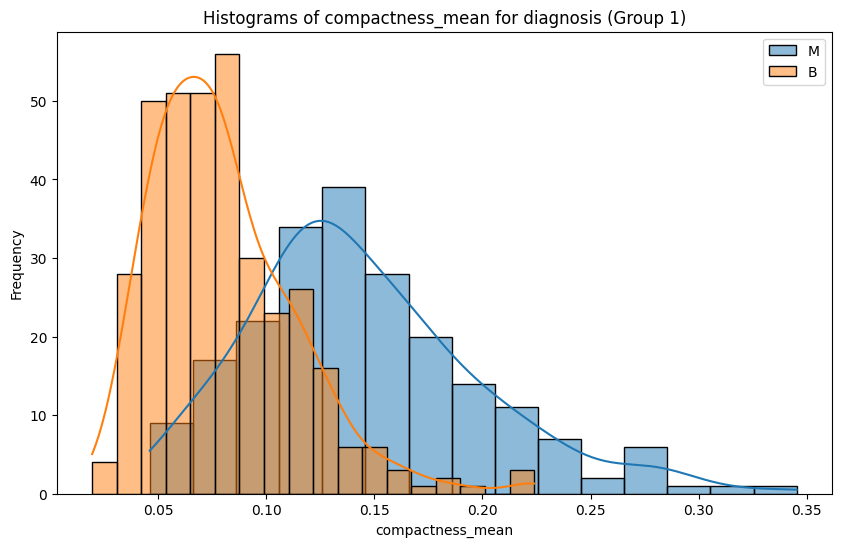

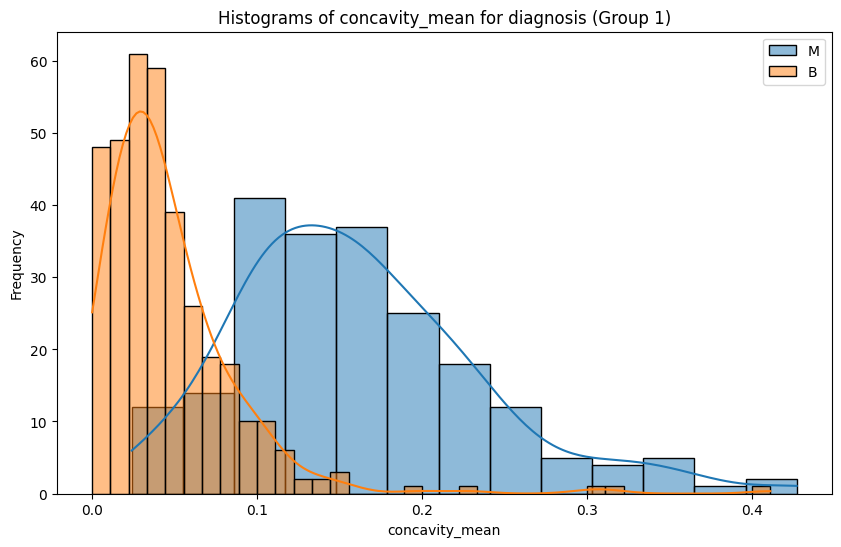

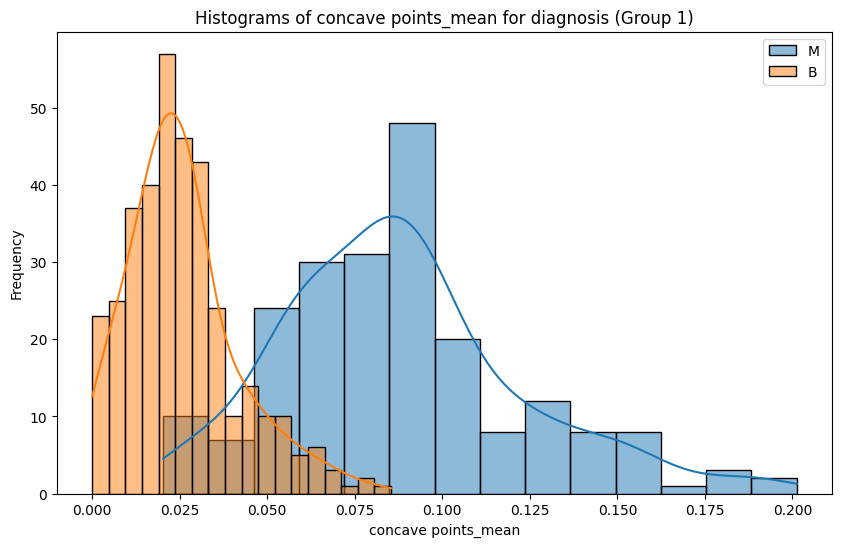

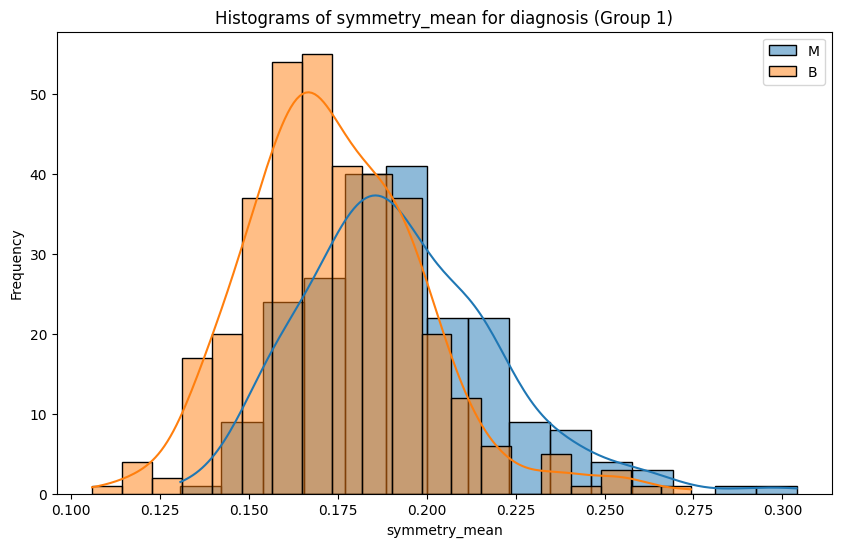

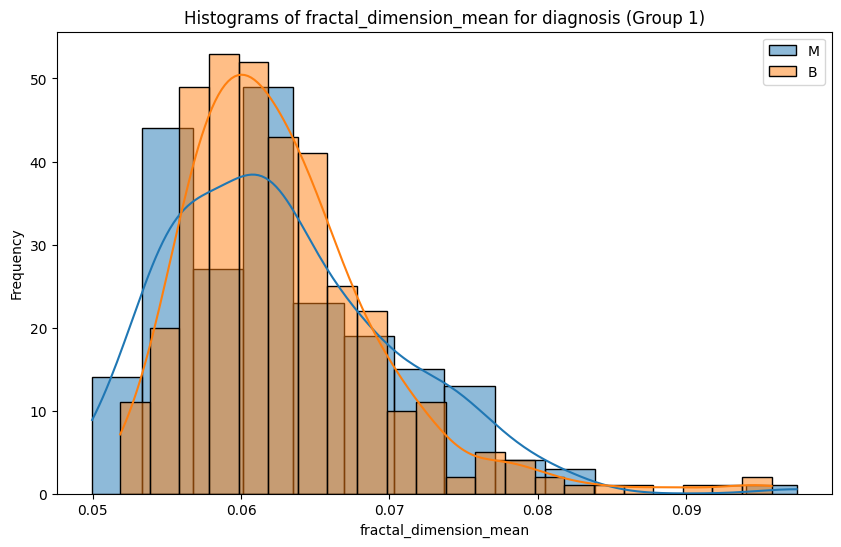

In [7]:
for col in col_num_mean:
    bt.plot_grouped_histograms(df, cat_col = target, num_col = col, group_size= df[target].nunique())

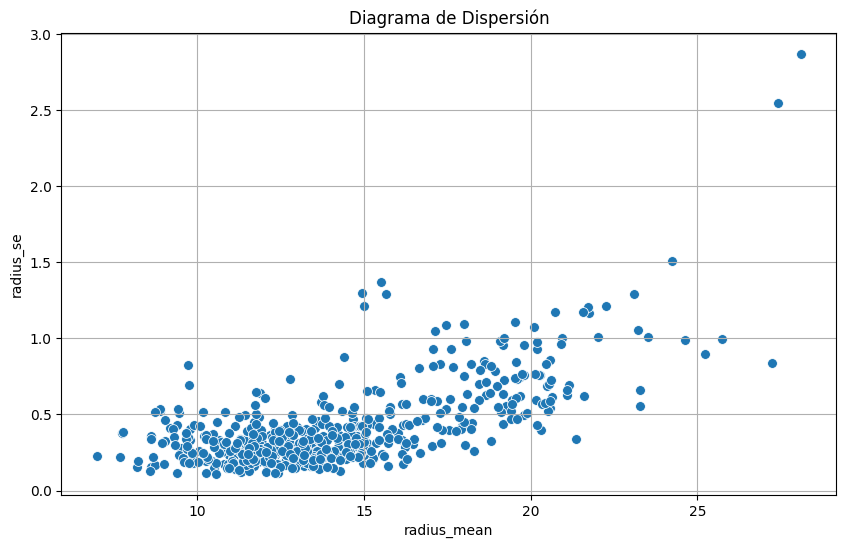

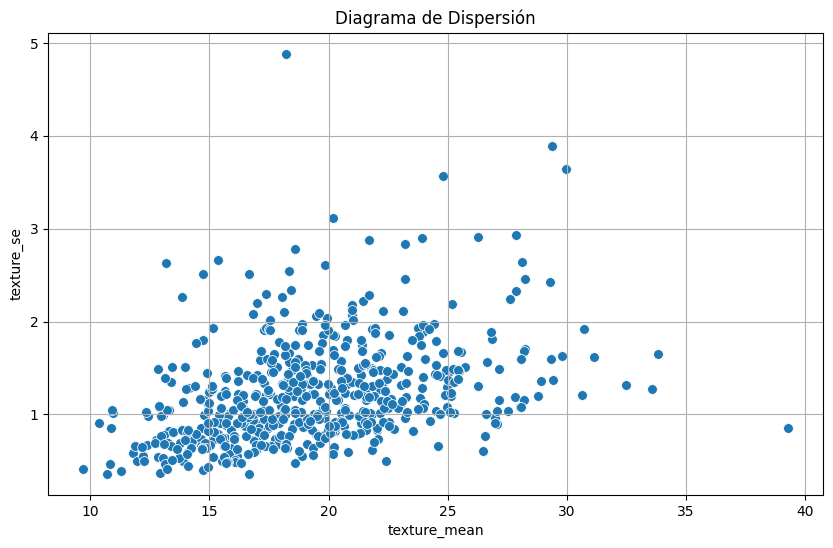

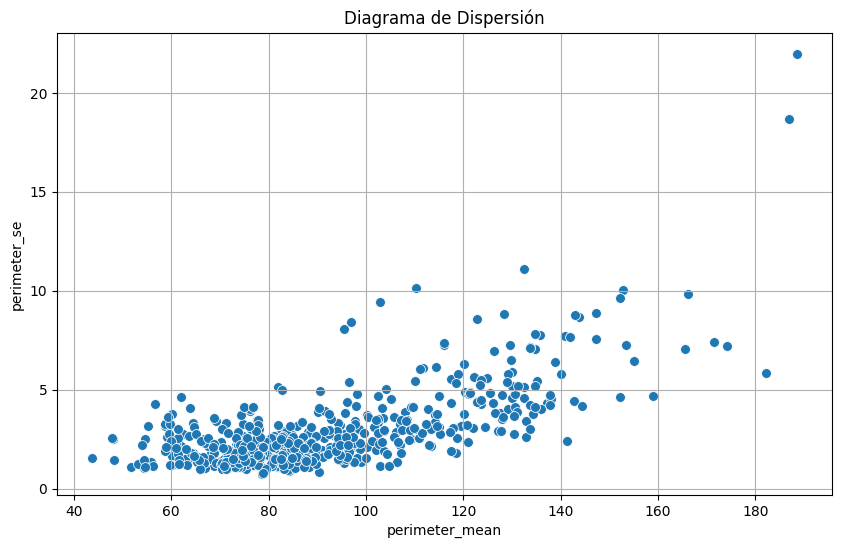

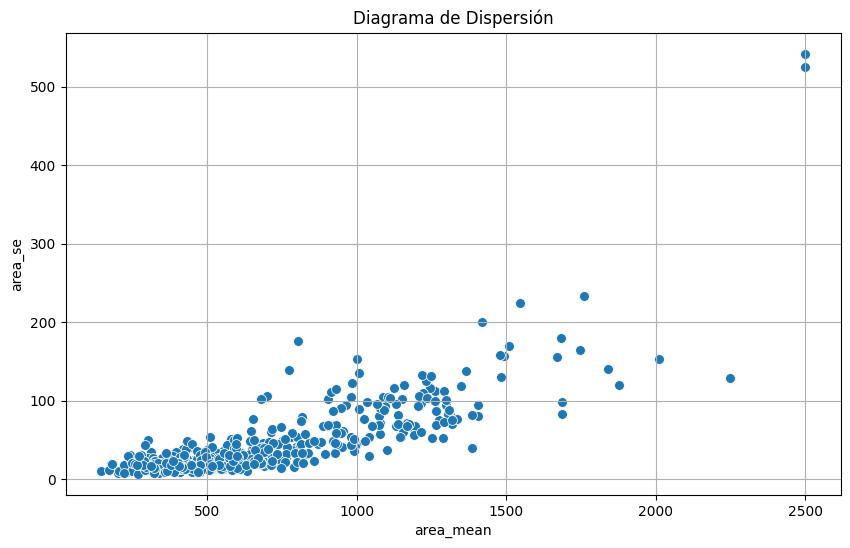

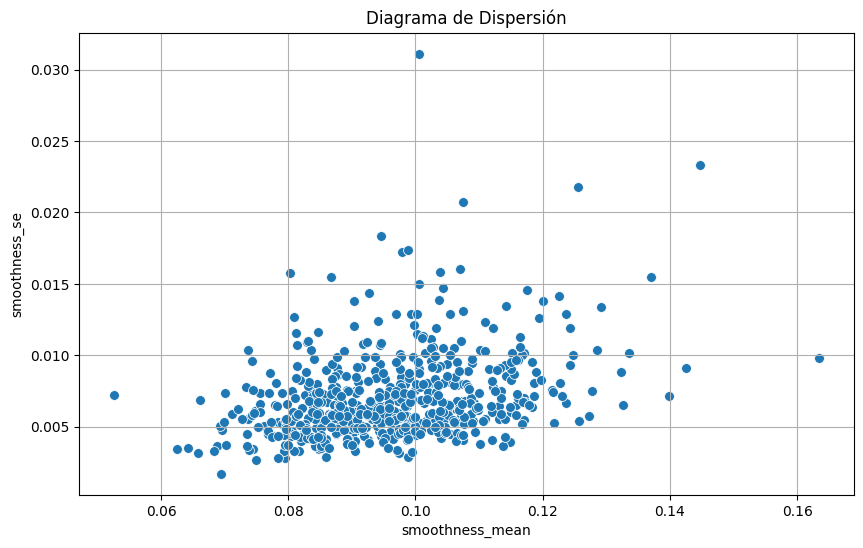

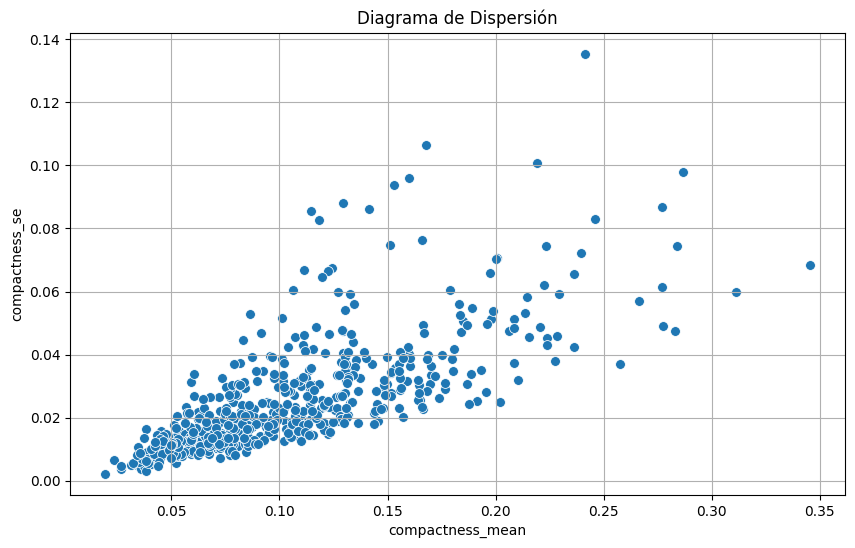

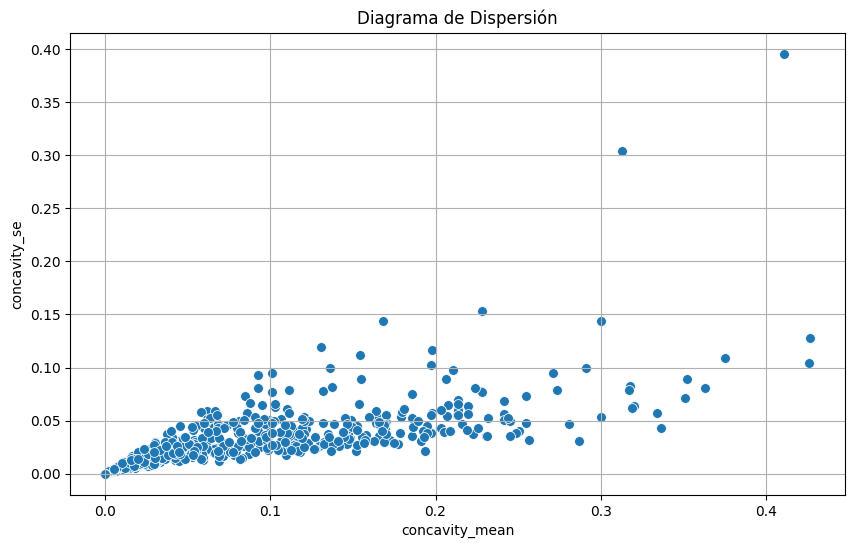

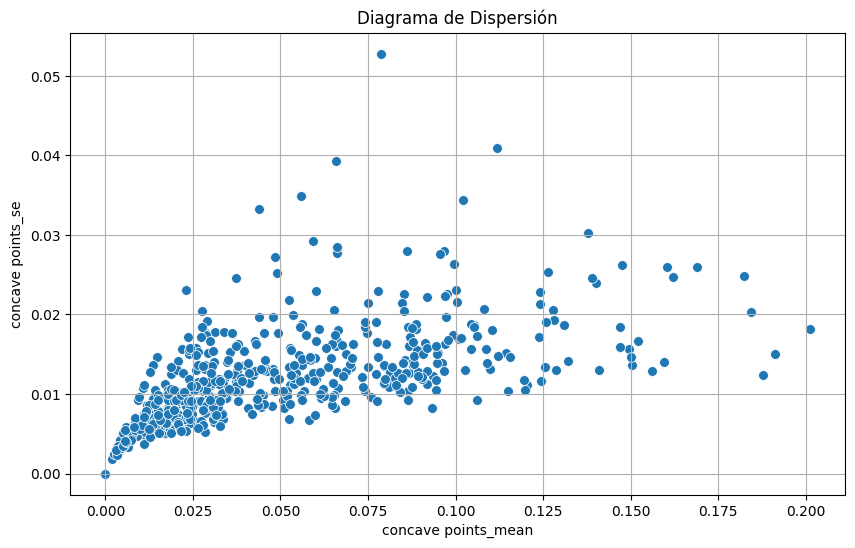

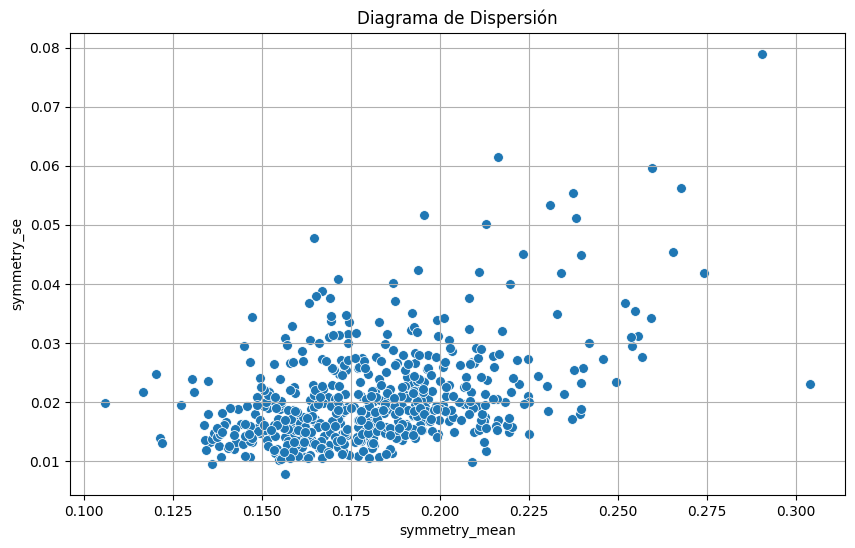

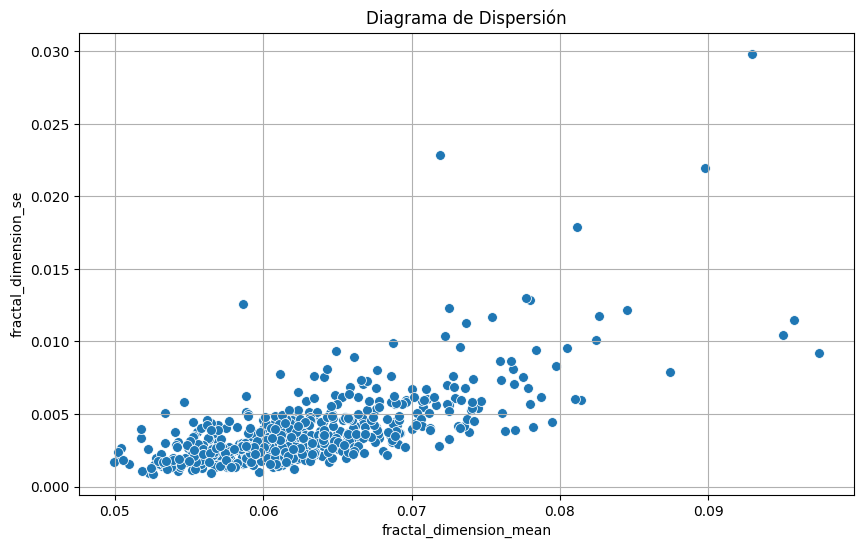

In [8]:
grupos_listas = [[a, b] for a, b in zip(col_num_mean, col_num_se)]

for a, b in grupos_listas:
    bt.grafico_dispersion_con_correlacion(df, a, b )

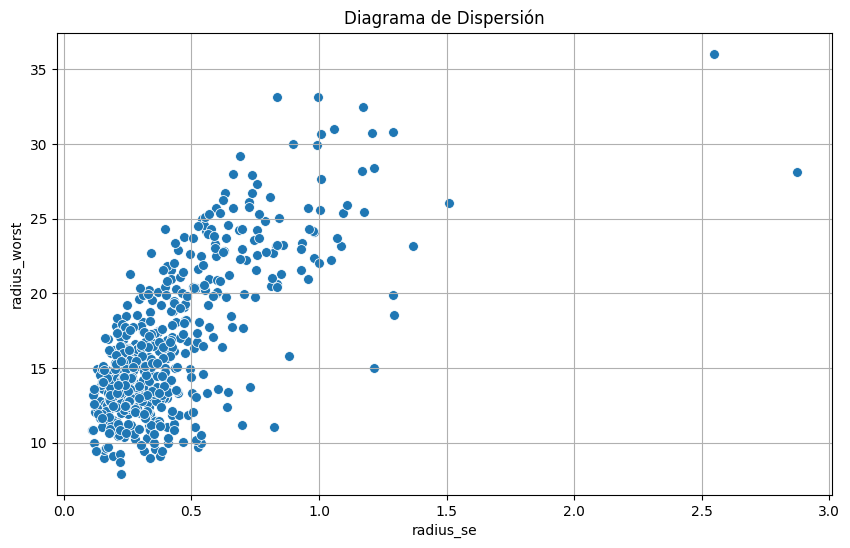

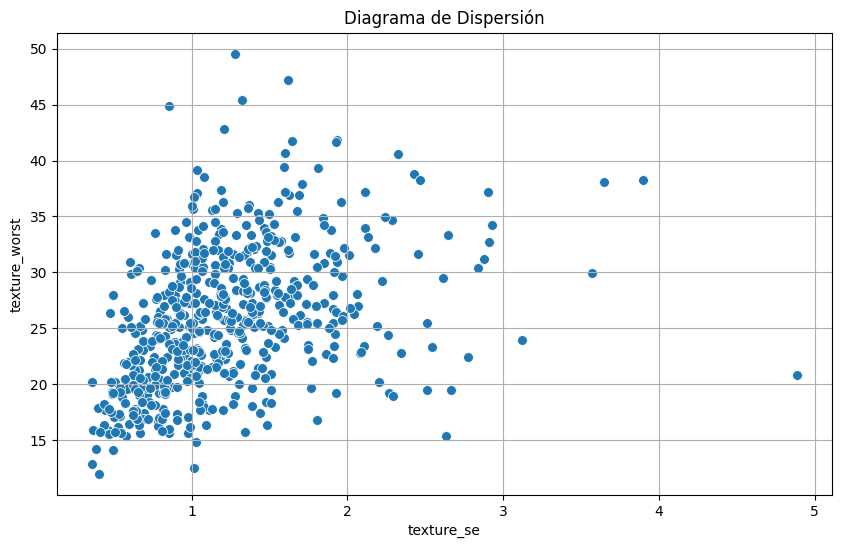

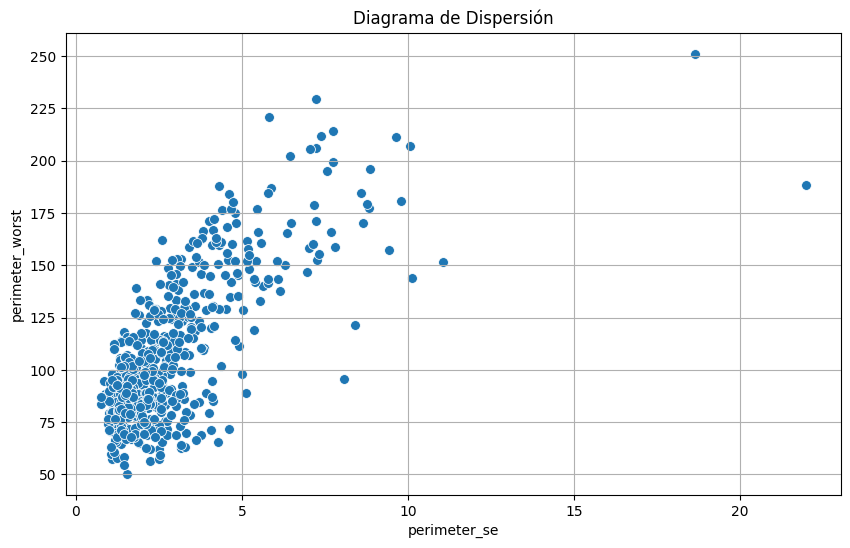

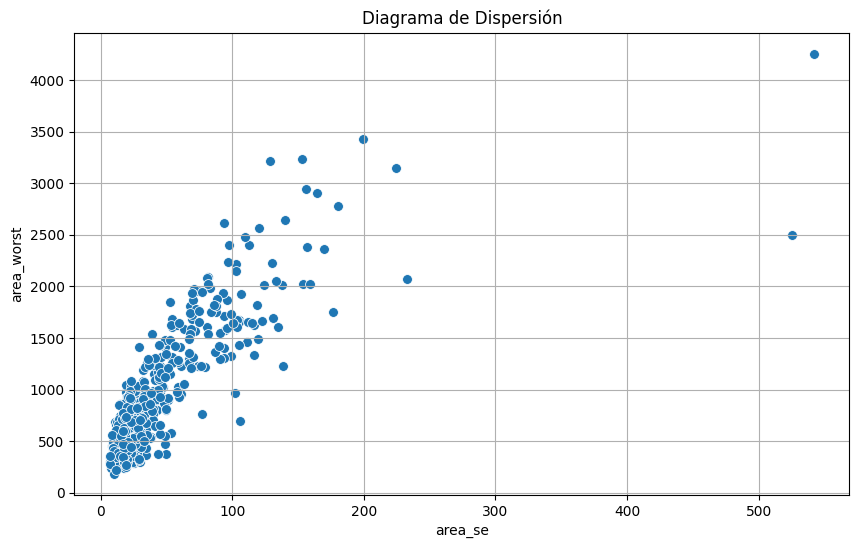

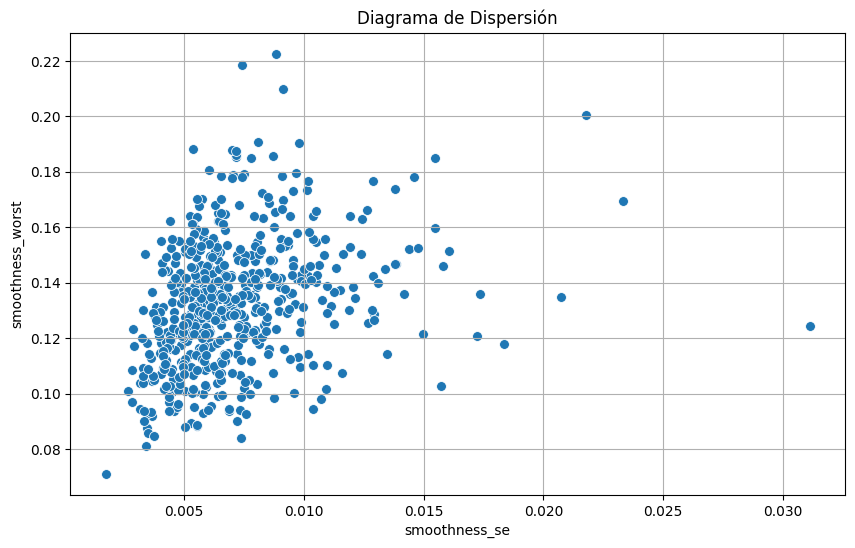

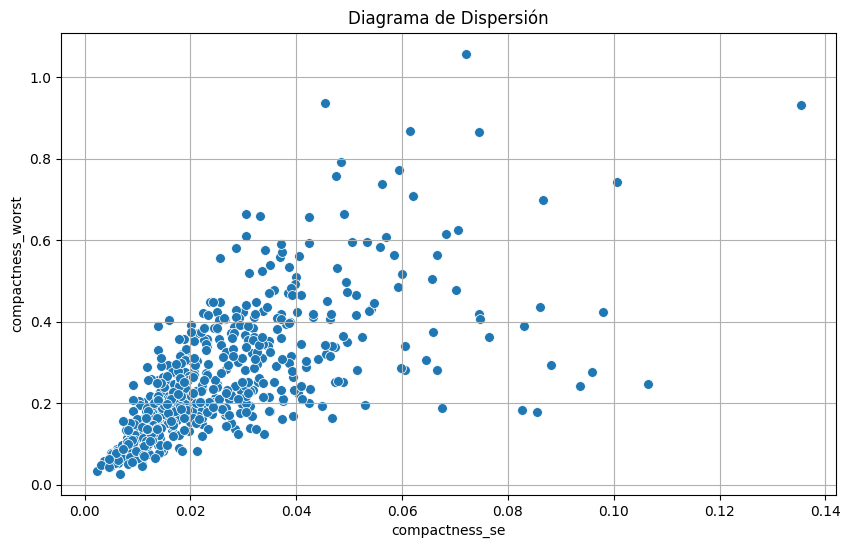

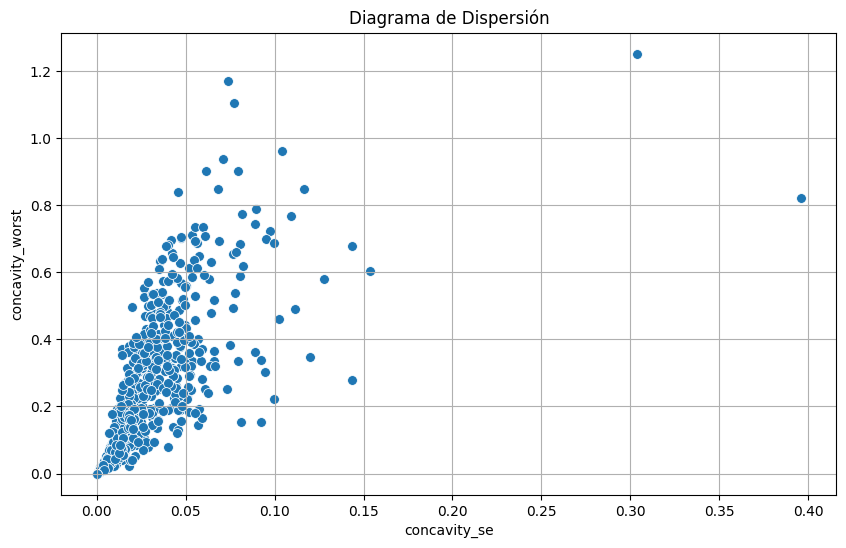

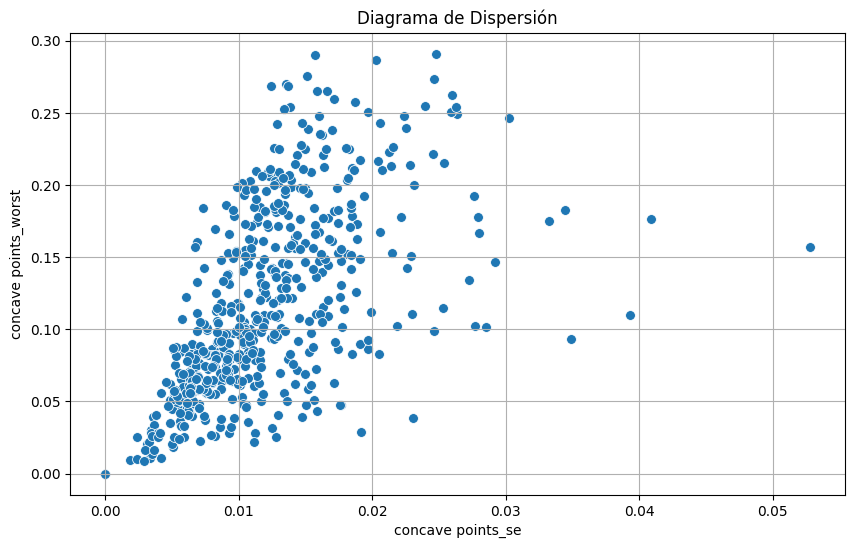

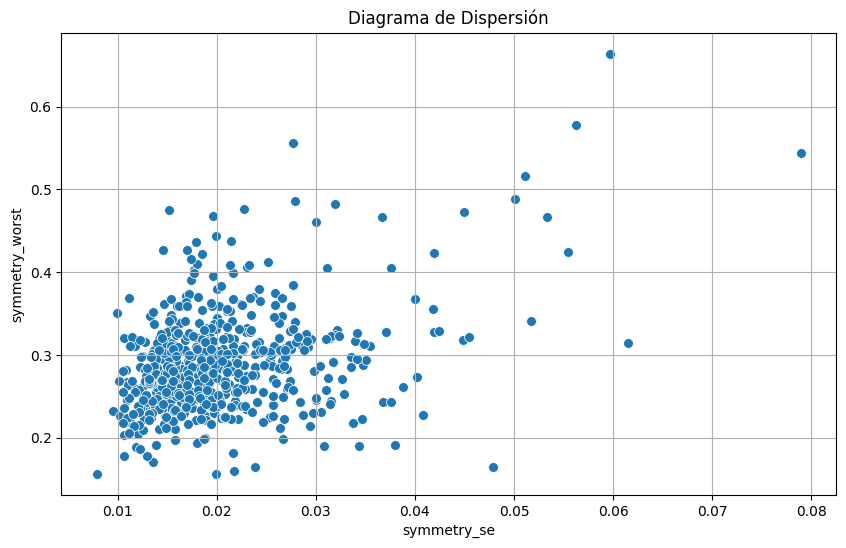

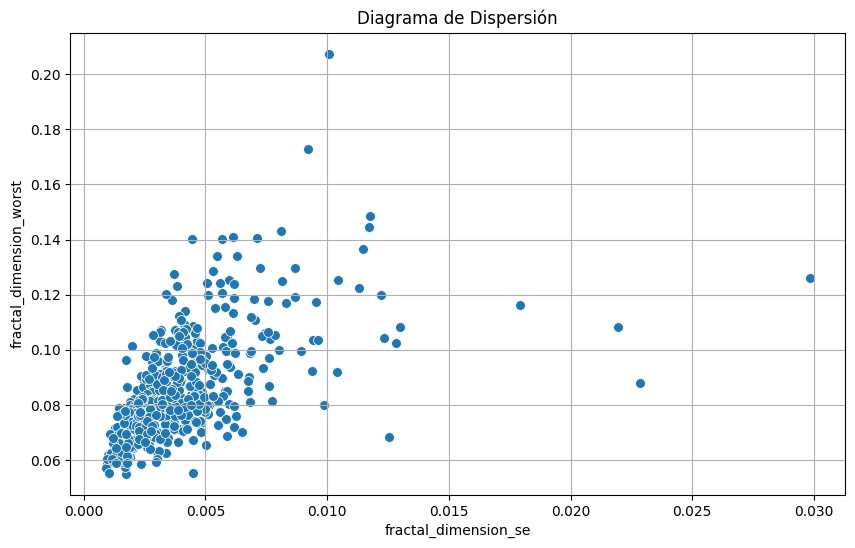

In [9]:
grupos_listas = [[a, b] for a, b in zip(col_num_se, col_num_worst)]

for a, b in grupos_listas:
    bt.grafico_dispersion_con_correlacion(df, a, b )

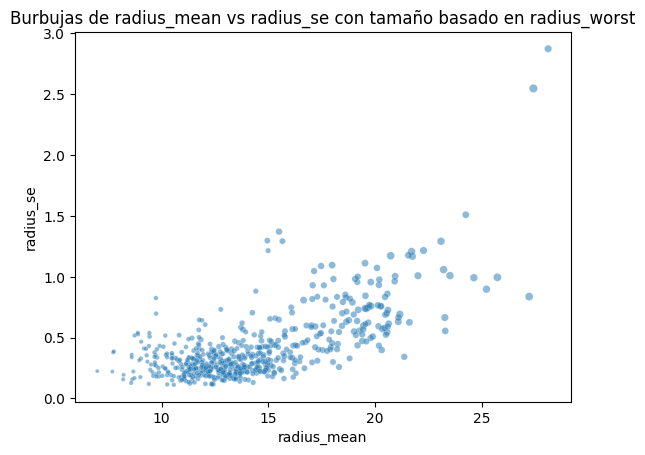

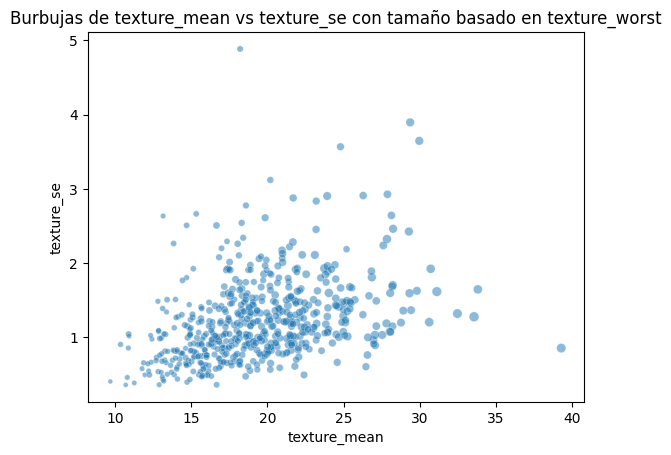

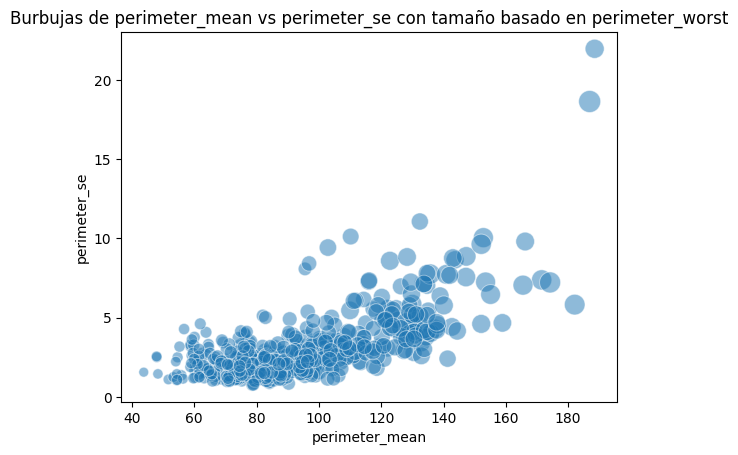

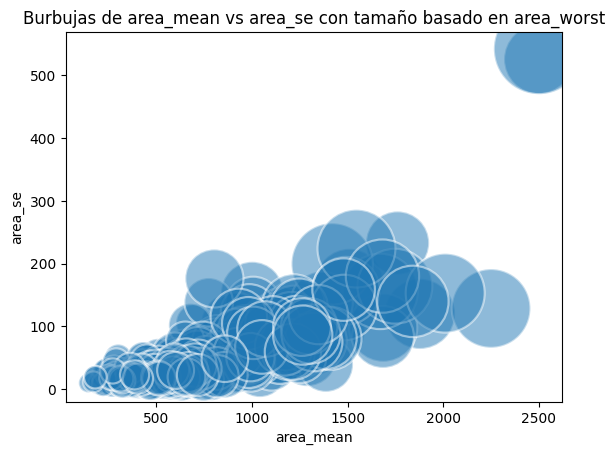

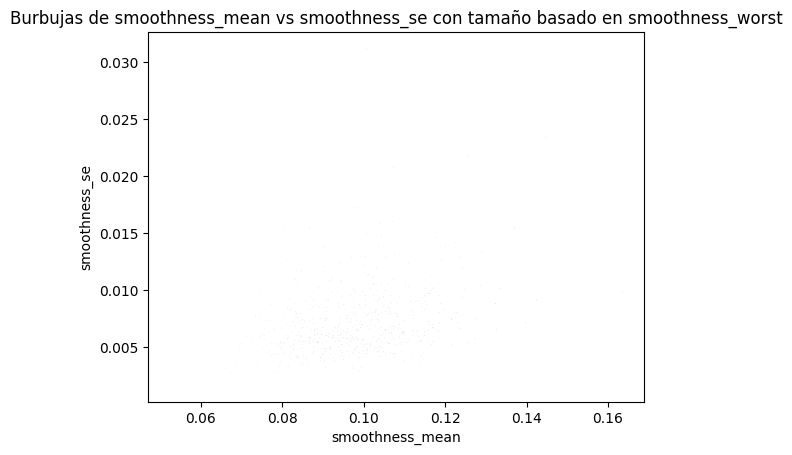

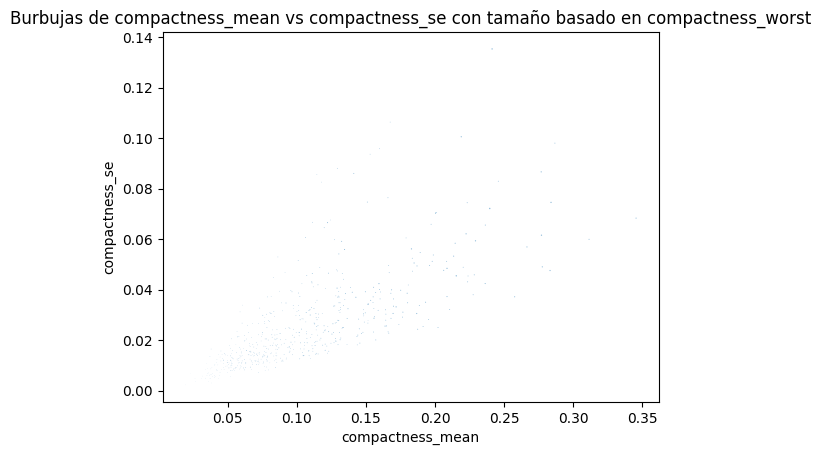

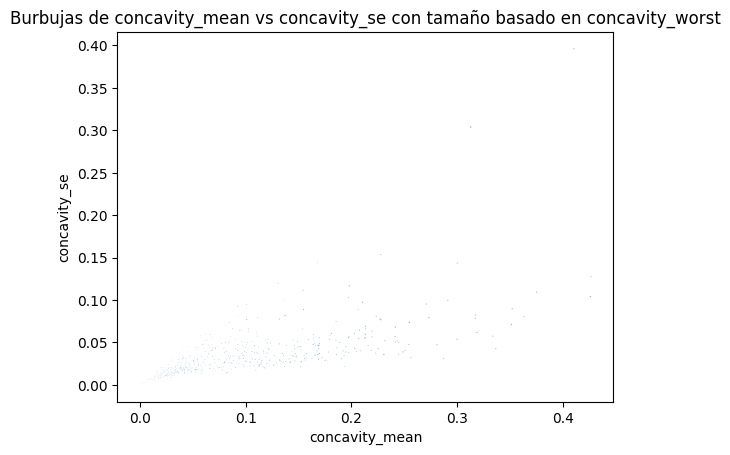

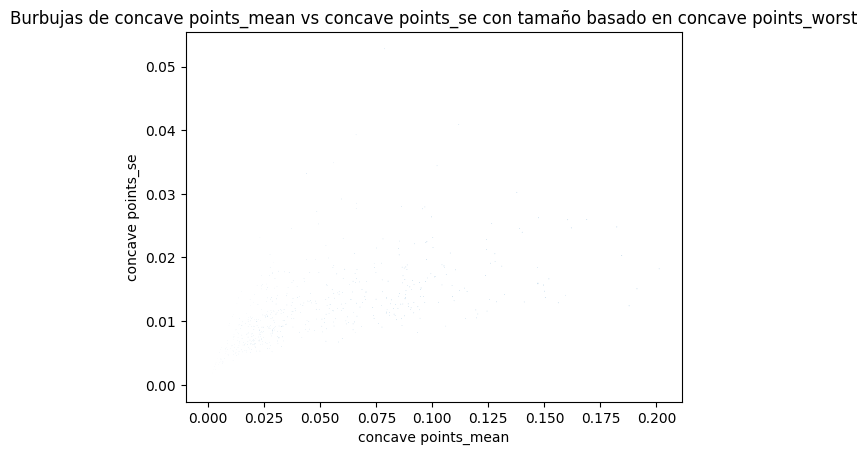

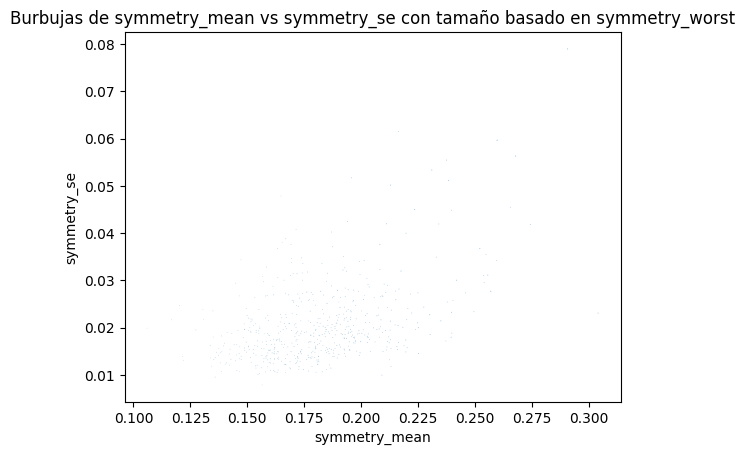

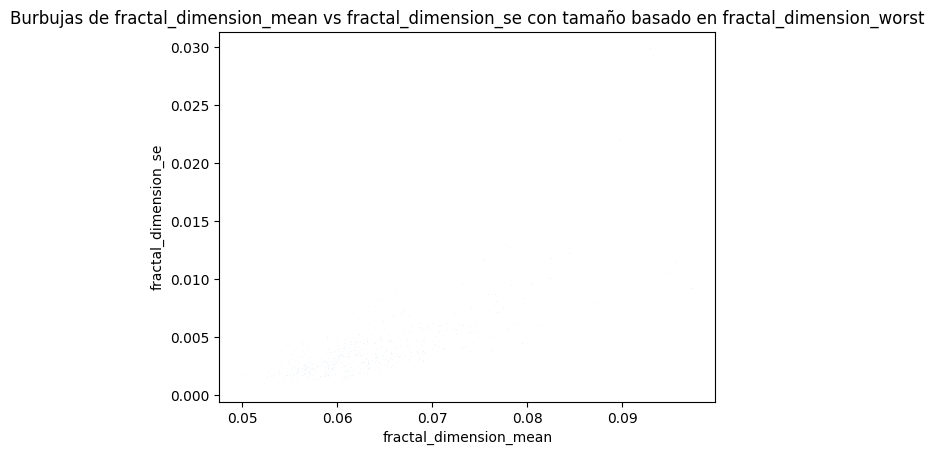

In [10]:
grupos_listas = [[a, b, c] for a, b, c in zip(col_num_mean, col_num_se, col_num_worst)]

for a, b, c in grupos_listas:
    sizes= df[c]
    sns.scatterplot(data= df, x=df[a], y=df[b], s=sizes, alpha=0.5)
    plt.xlabel(a)
    plt.ylabel(b)
    plt.title(f"Burbujas de {a} vs {b} con tamaño basado en {c}")
    plt.show()

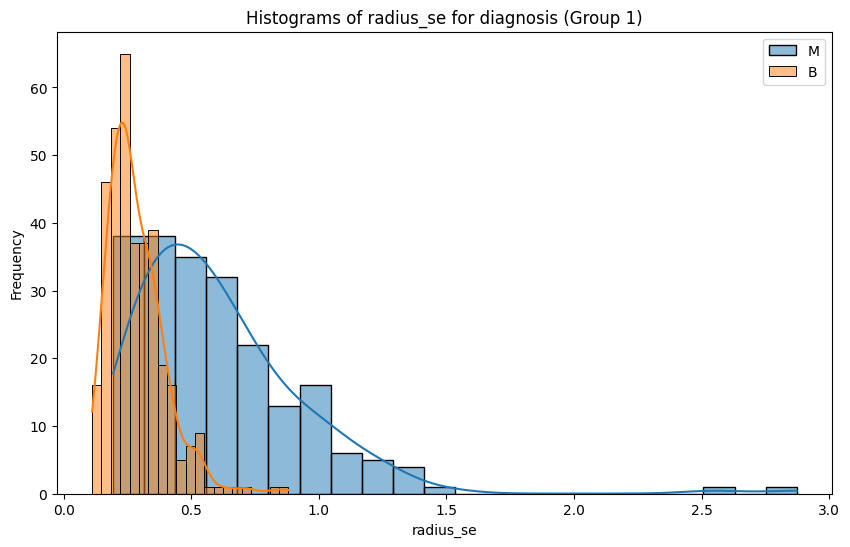

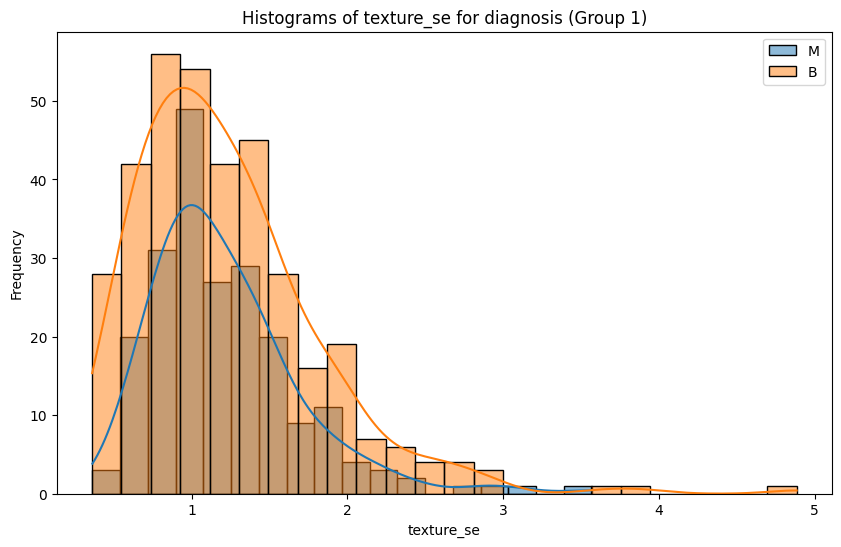

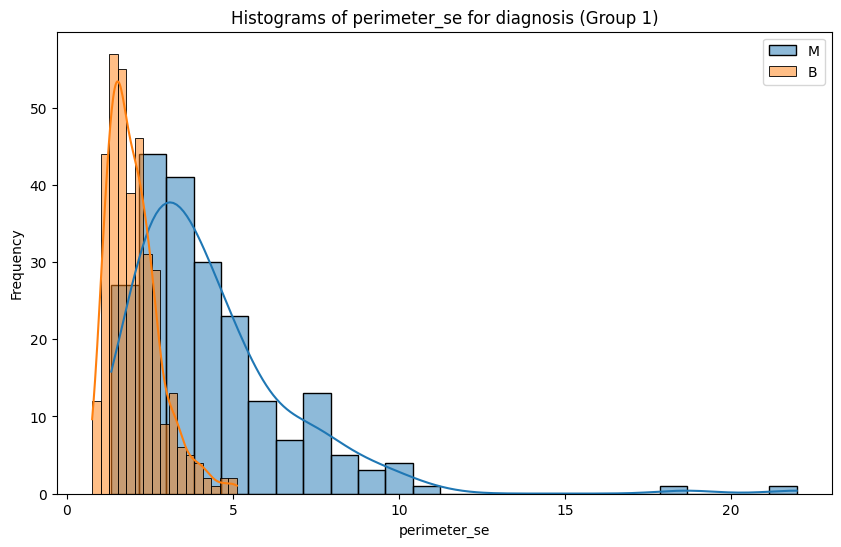

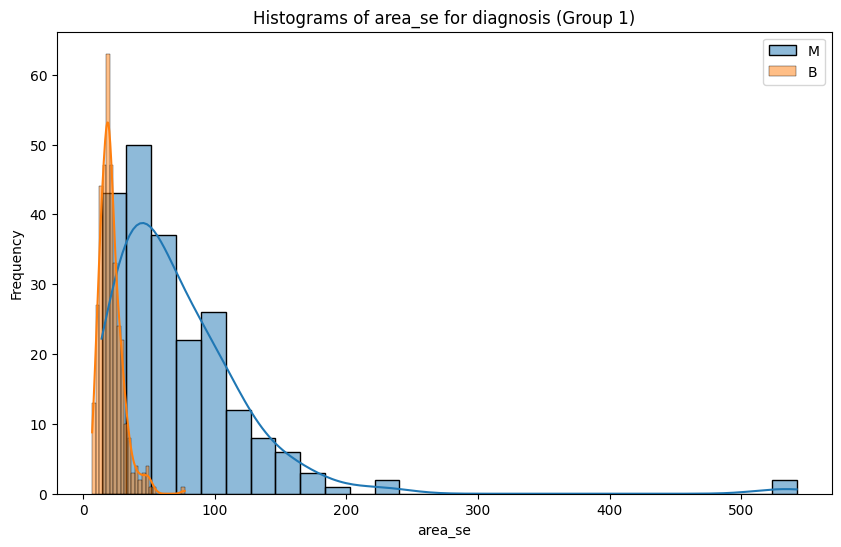

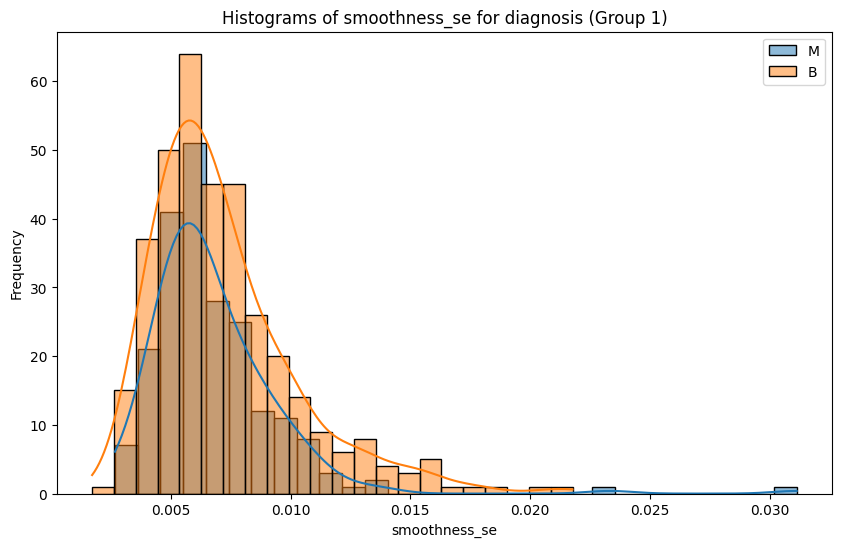

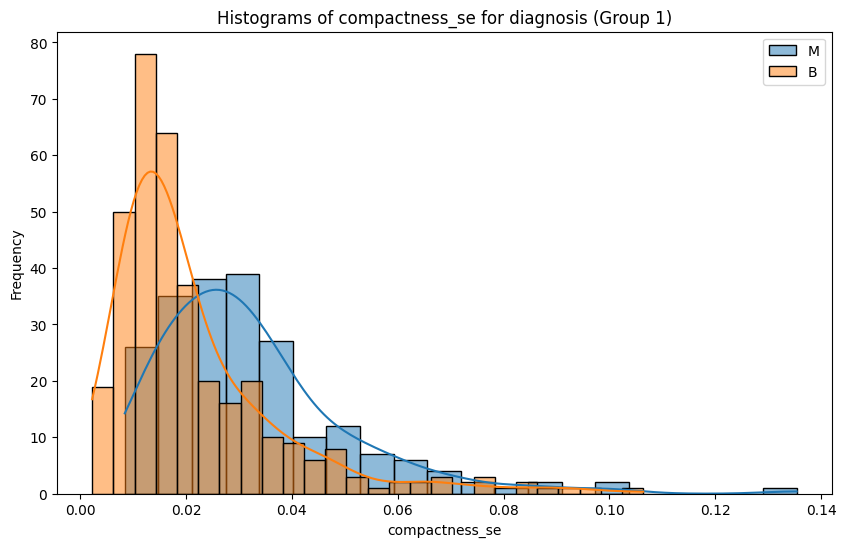

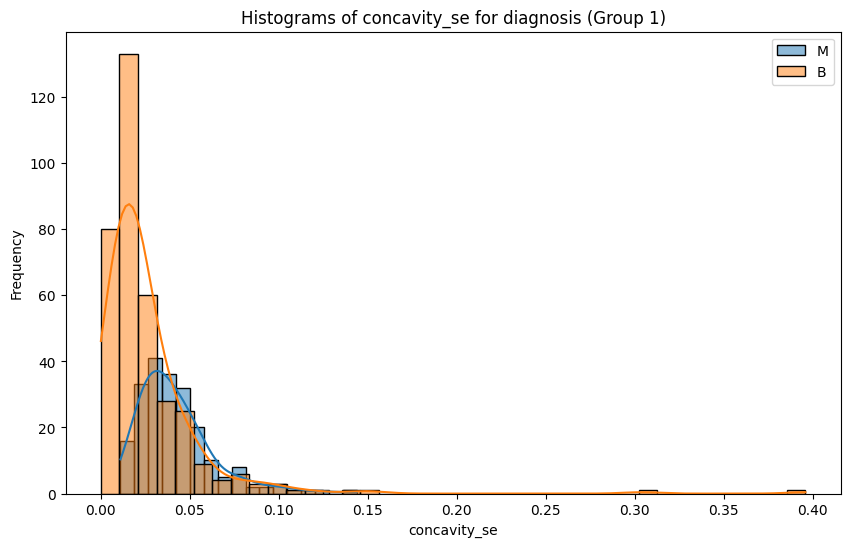

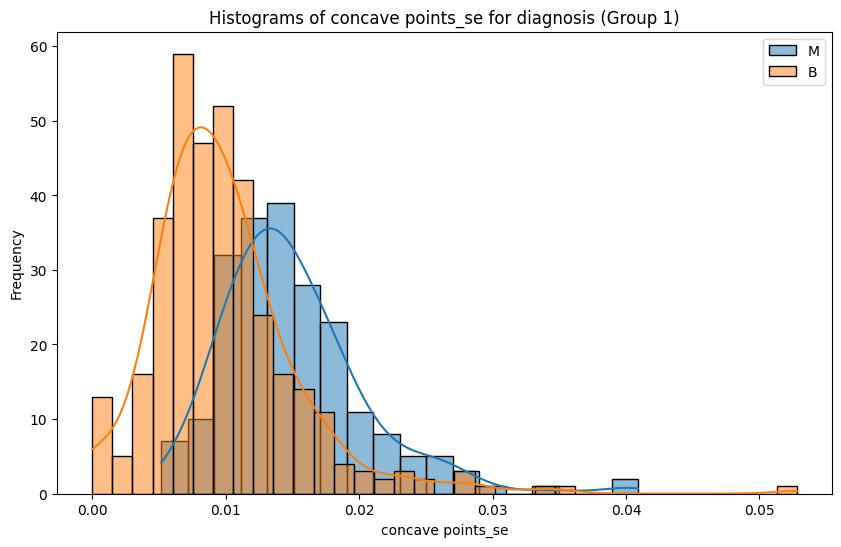

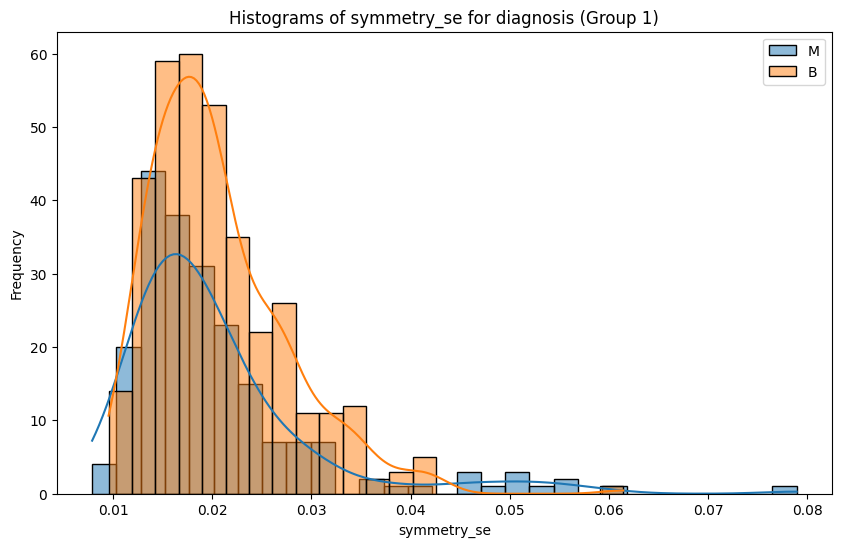

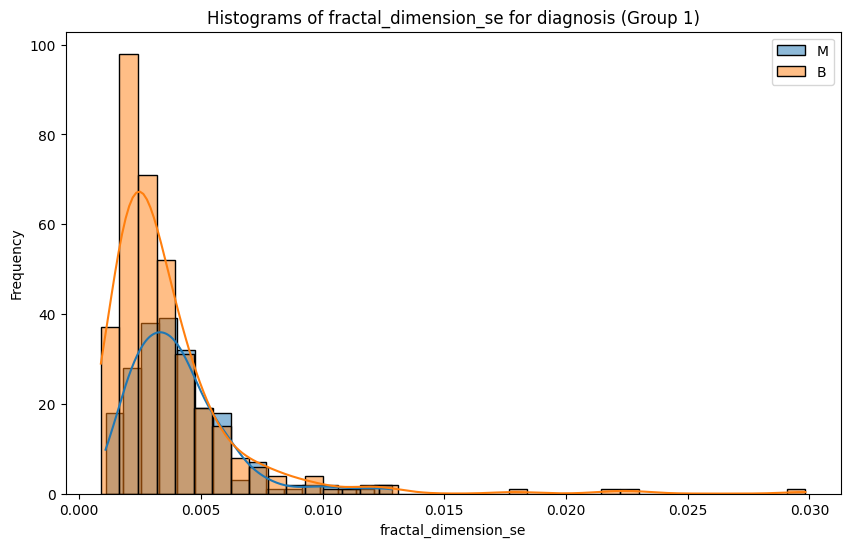

<Figure size 640x480 with 0 Axes>

In [11]:
for col in col_num_se:
    bt.plot_grouped_histograms(df, 
                               cat_col=target, 
                               num_col=col, 
                               group_size=df[target].nunique())  # solo si la función lo soporta
plt.tight_layout()
plt.show()

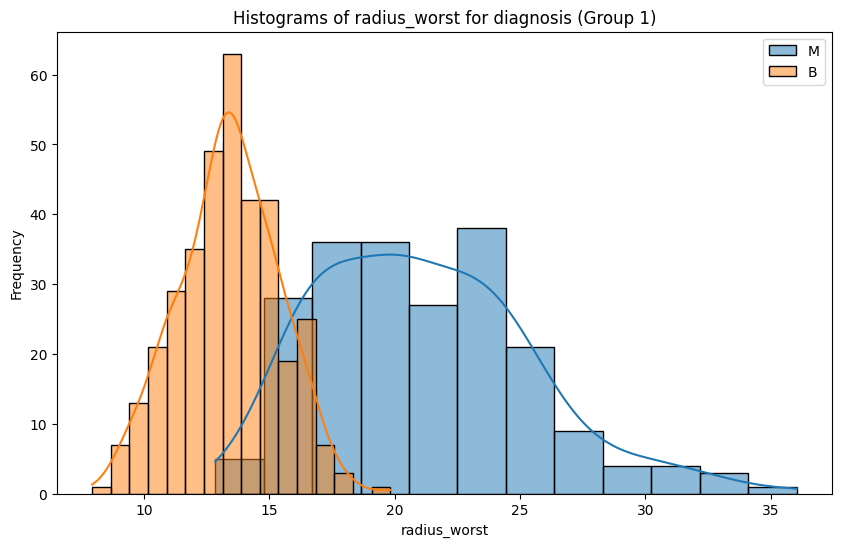

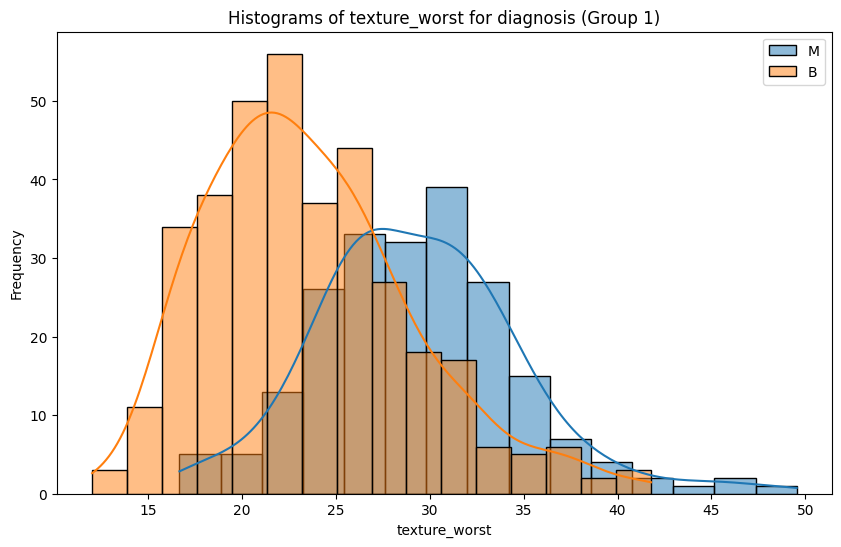

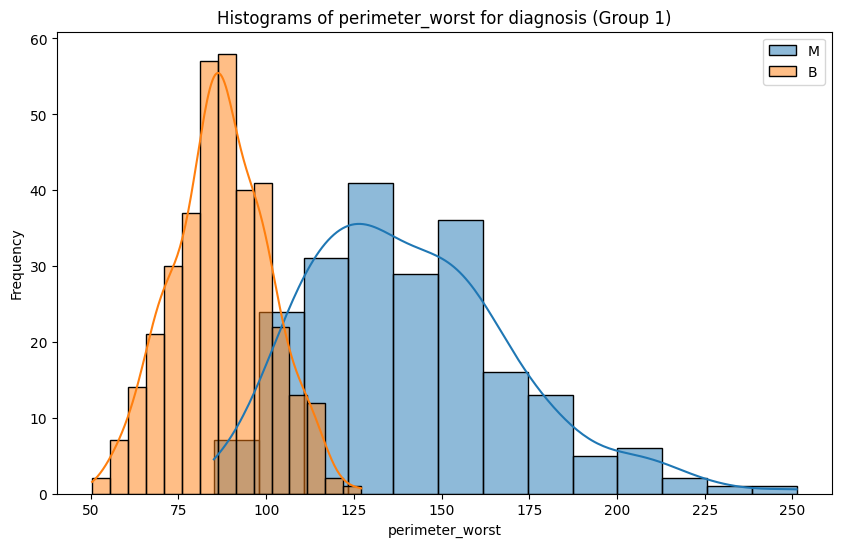

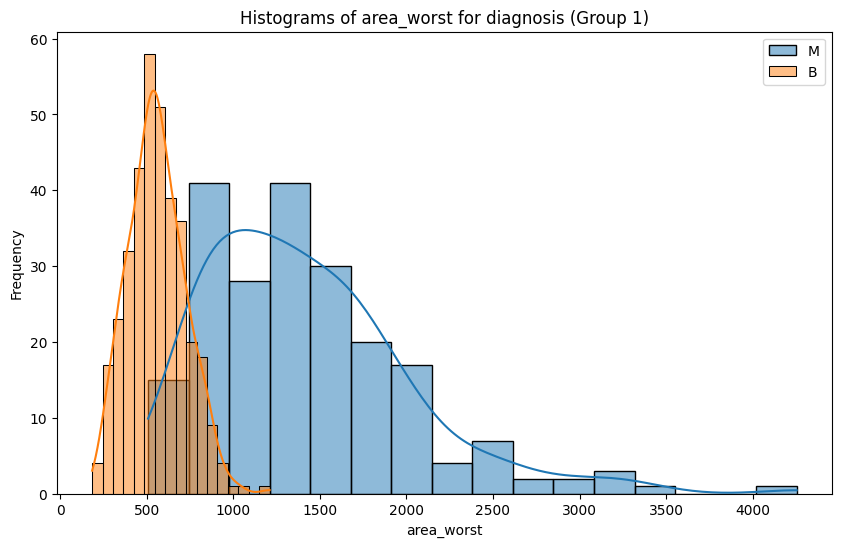

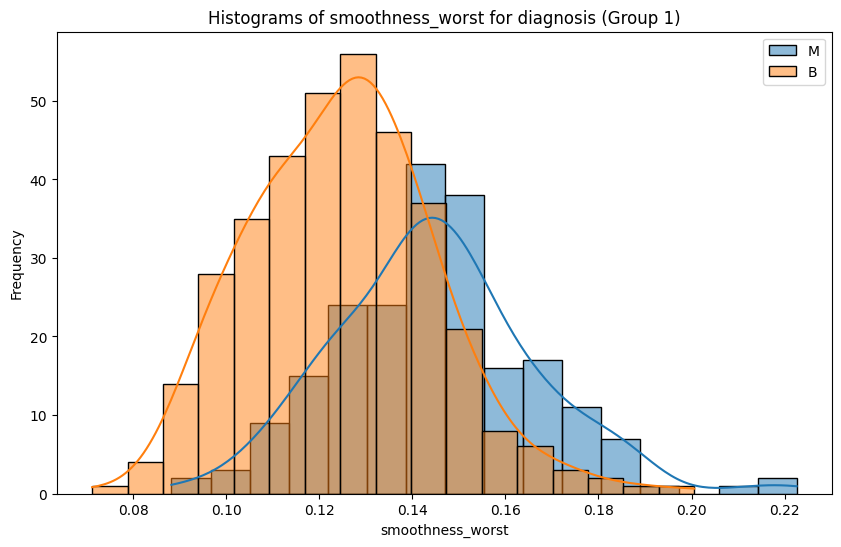

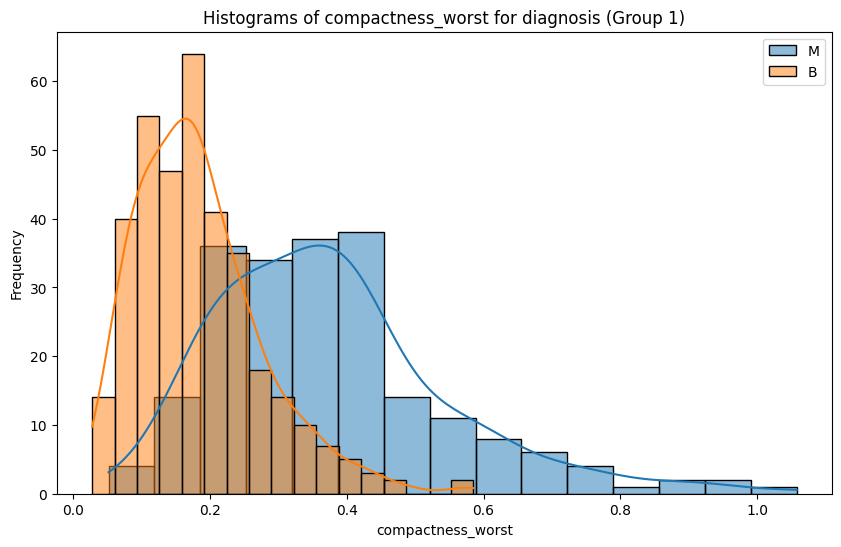

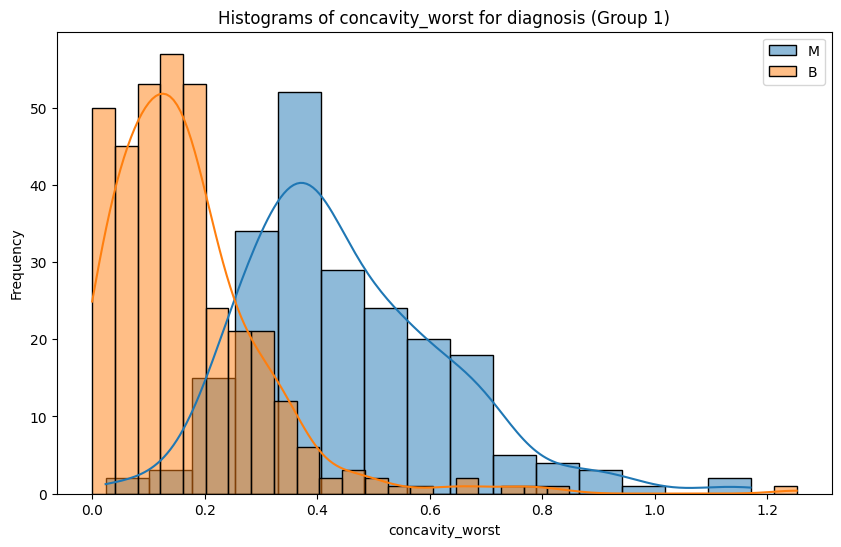

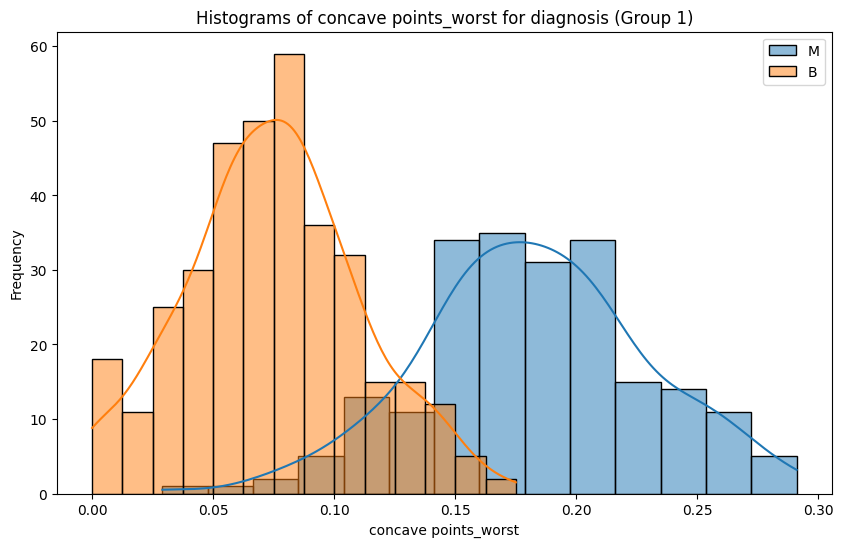

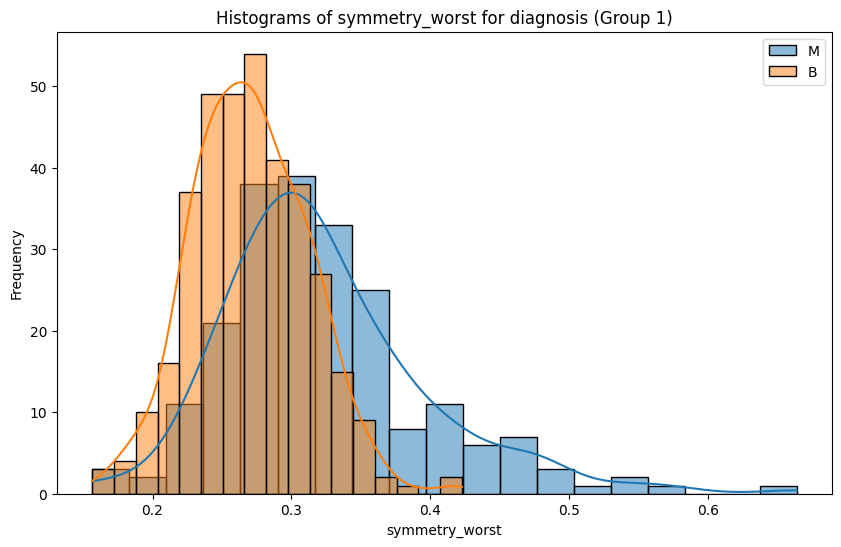

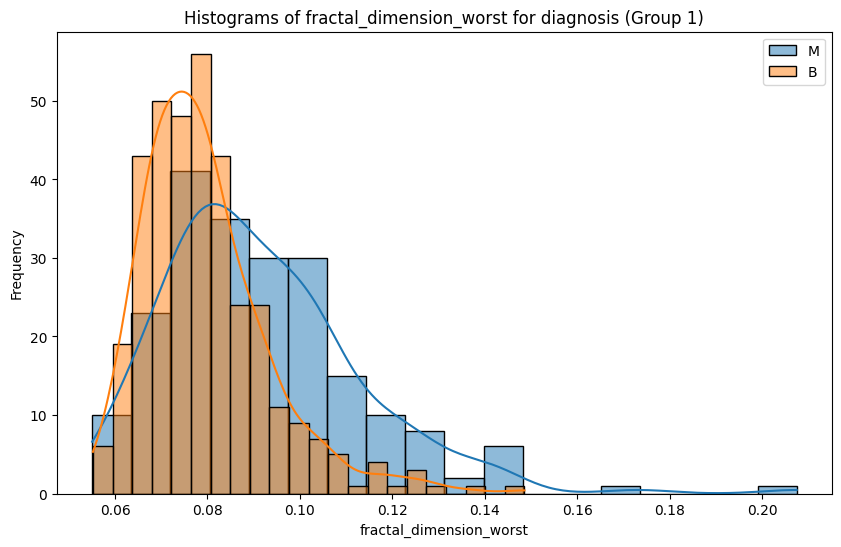

<Figure size 640x480 with 0 Axes>

In [12]:
for col in col_num_worst:
    bt.plot_grouped_histograms(df, 
                               cat_col=target, 
                               num_col=col, 
                               group_size=df[target].nunique())  # solo si la función lo soporta
plt.tight_layout()
plt.show()

### Ejercicio 2:

Descarta las características que evidentemente no aportan información.

In [13]:
print(target)
print(col_num_mean)
print(col_num_se)
print(col_num_worst)

diagnosis
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']
['radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se']
['radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [14]:
col_excluidas = ["texture_se", "smoothness_se"] # No tienen ninguna diferencia con respecto al target


In [15]:
col_num_se.remove("texture_se")

In [16]:
col_num_se.remove("smoothness_se")

In [17]:
print(target)
print(col_num_mean)
print(col_num_se)
print(col_num_worst)
print(col_excluidas)

diagnosis
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']
['radius_se', 'perimeter_se', 'area_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se']
['radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']
['texture_se', 'smoothness_se']


### Ejercicio 3: 

Divide en train y test. Analiza el target de forma breve.

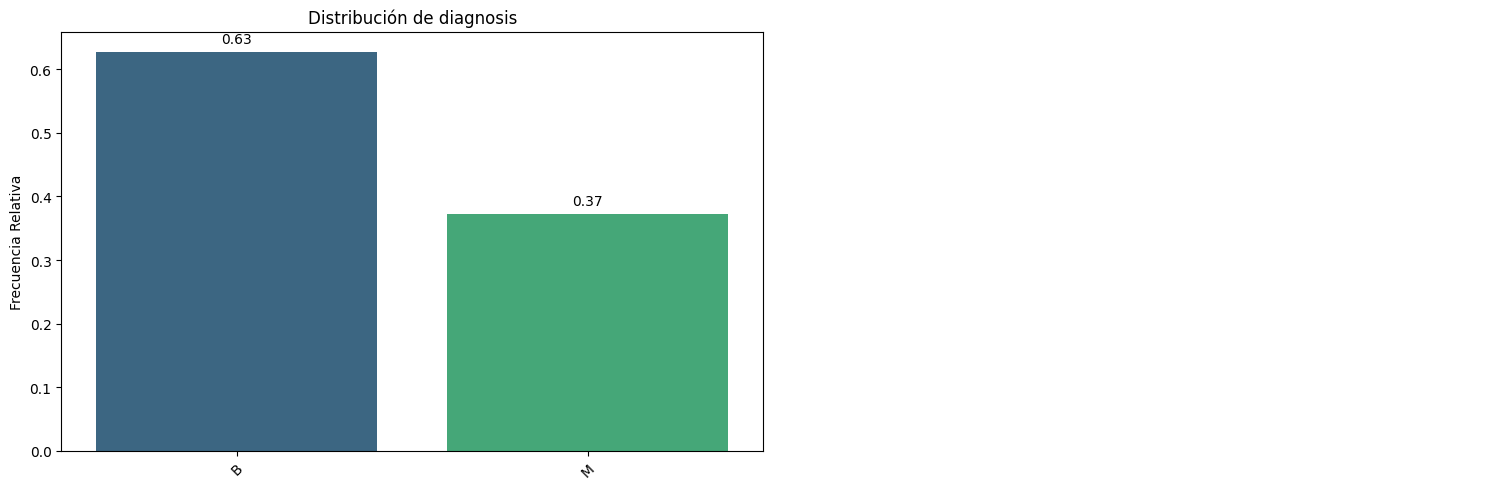

In [18]:
bt.pinta_distribucion_categoricas(df, columnas_categoricas=[target],relativa=True, mostrar_valores=True)

In [19]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df[col_num_mean + col_num_se + col_num_worst + [target]], test_size=0.2, stratify=df[target], random_state=42)

print(train_set.shape)
print(test_set.shape)

(455, 29)
(114, 29)


### Ejercicio 4: MiniEDA (I) Análisis Visual

Realiza un análisis visual de las features y haz tu selección de primera "división" (que luego usaremos para comparar con otros métodos de selección).

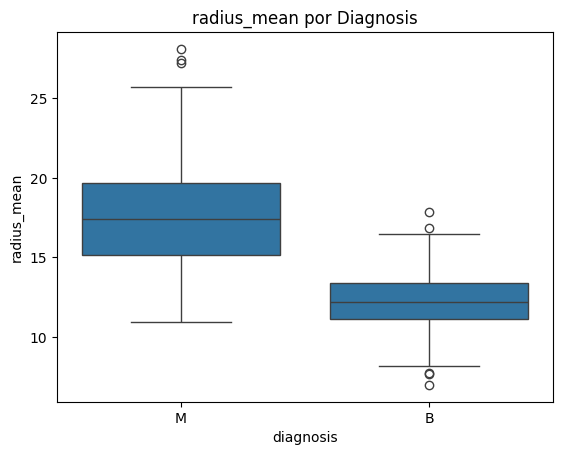

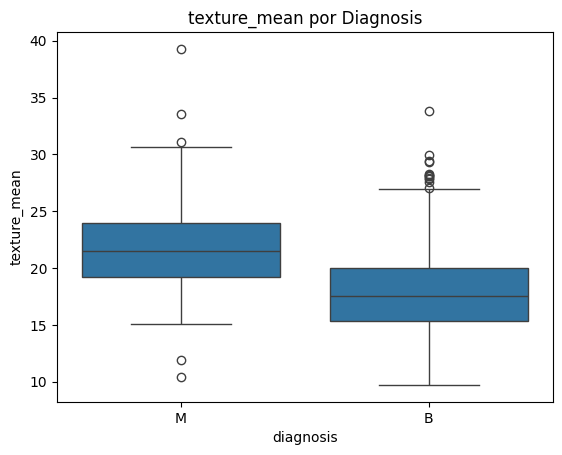

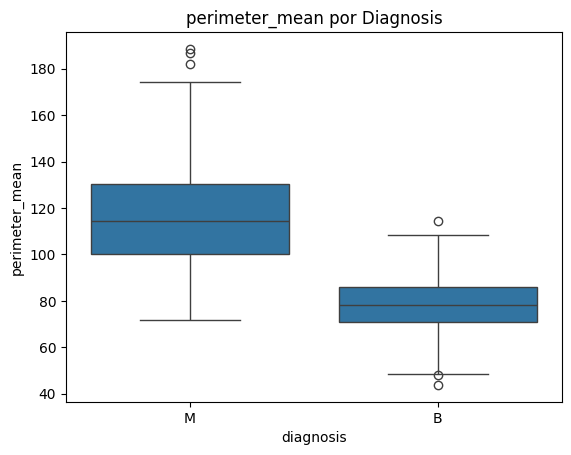

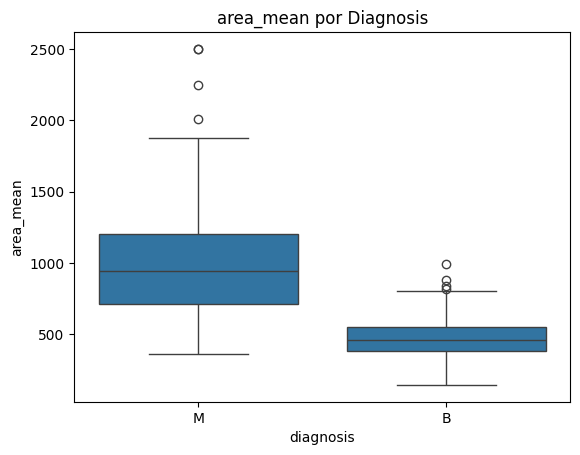

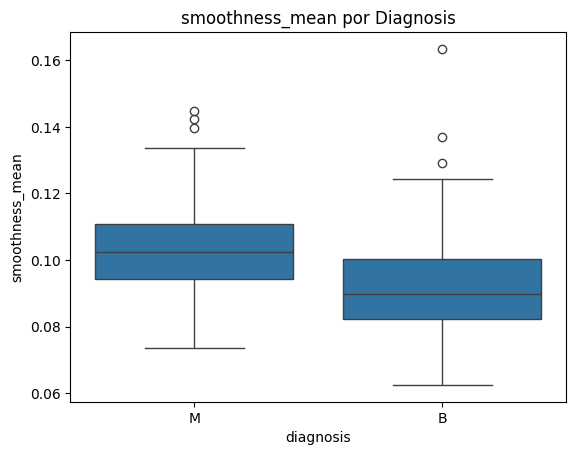

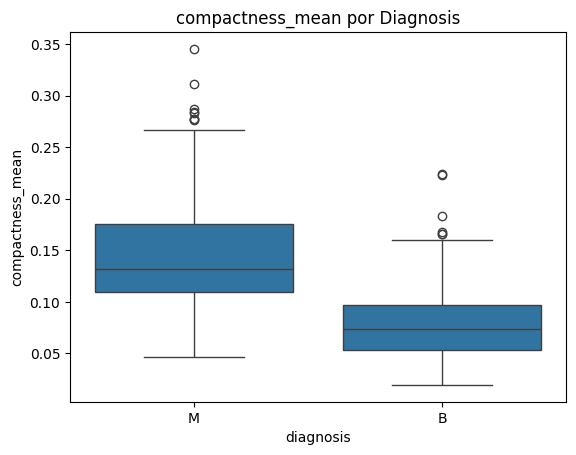

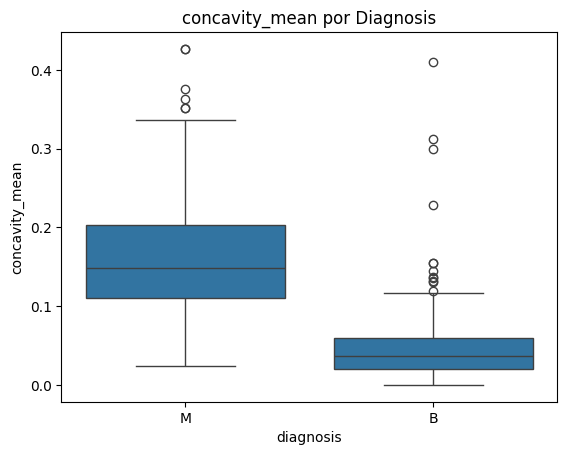

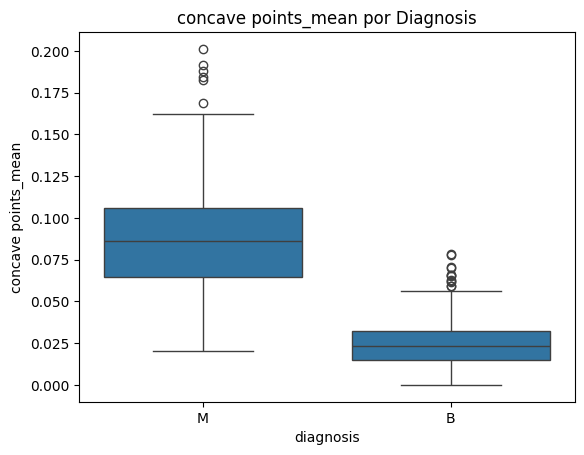

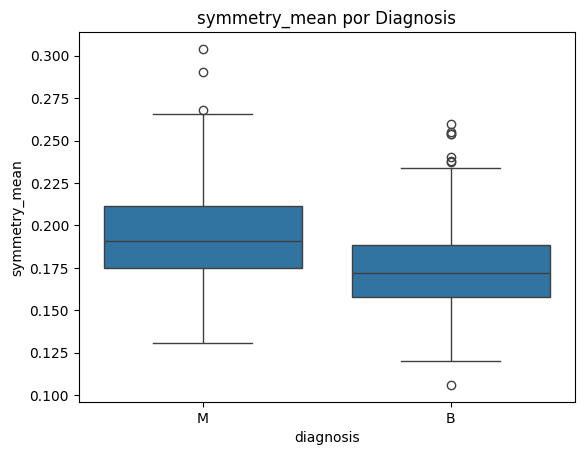

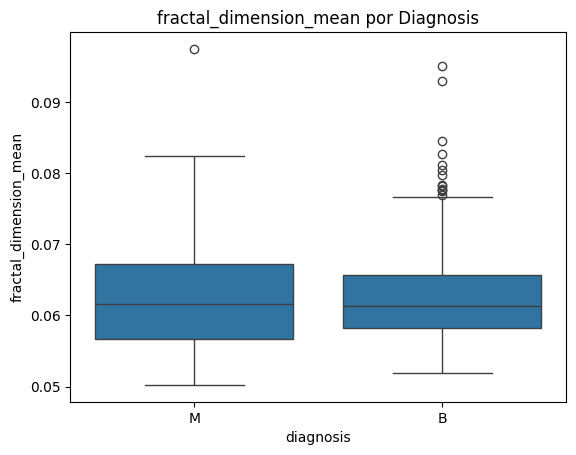

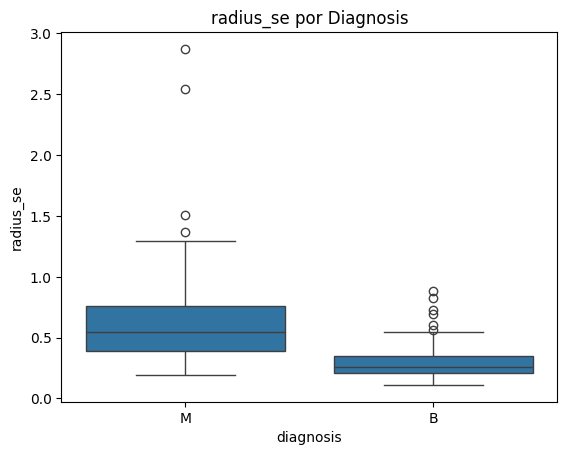

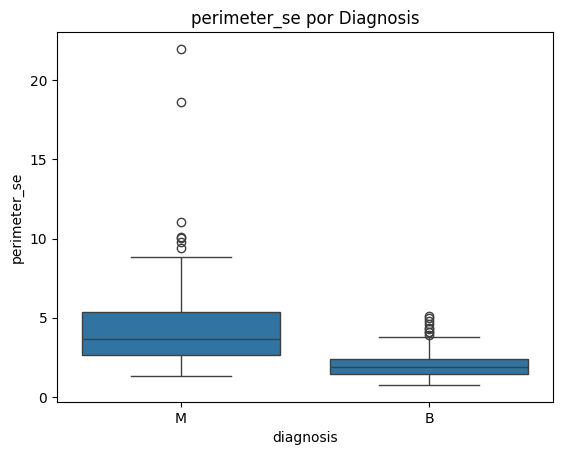

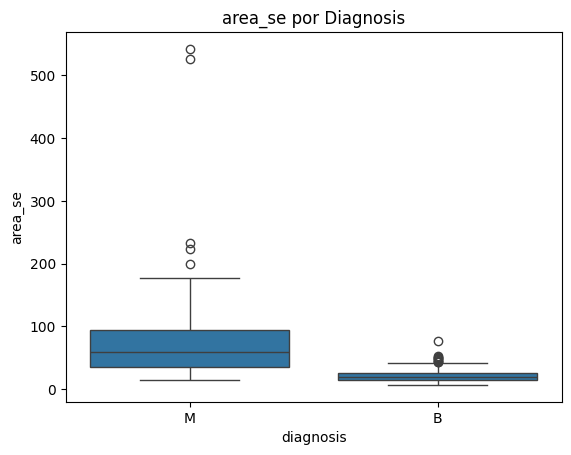

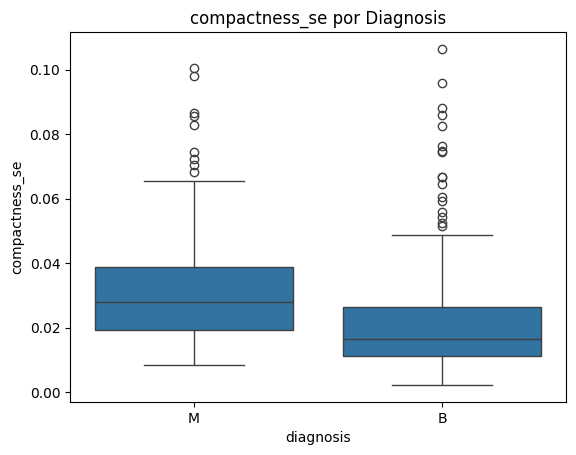

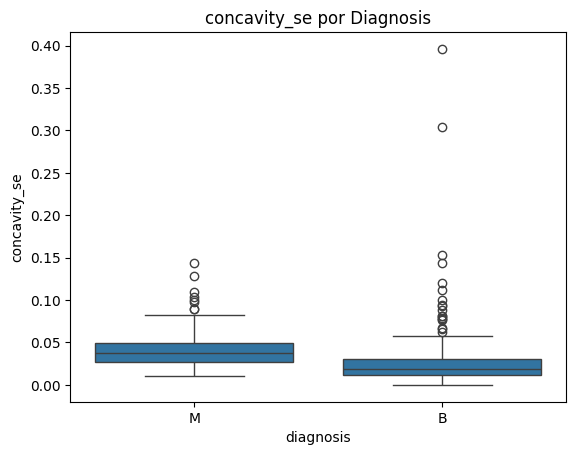

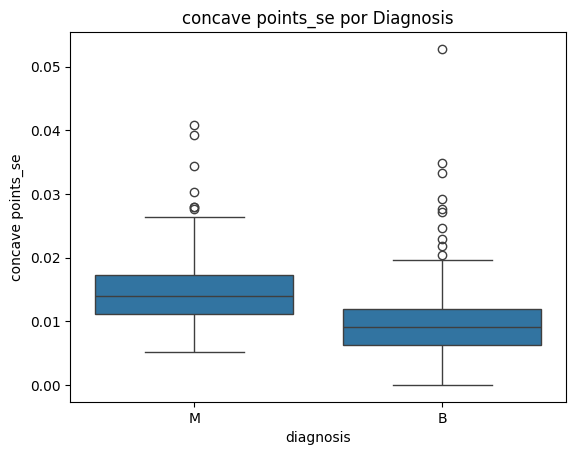

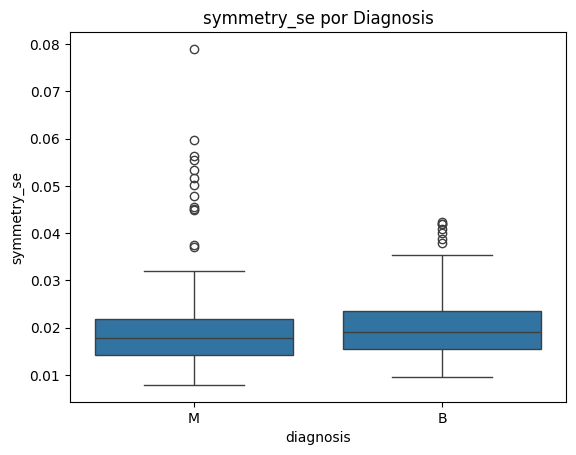

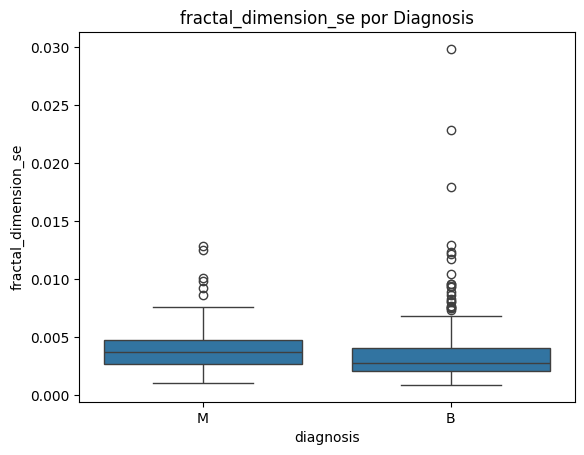

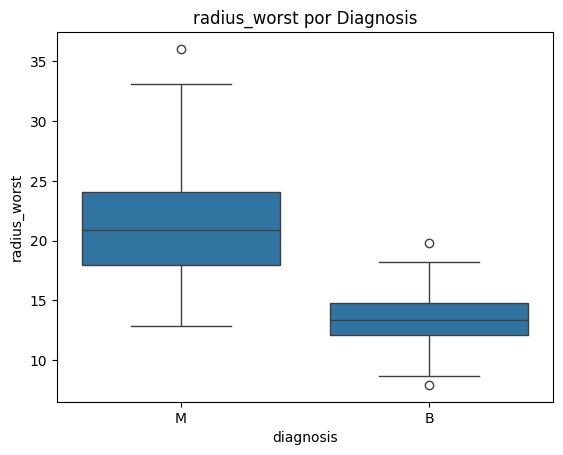

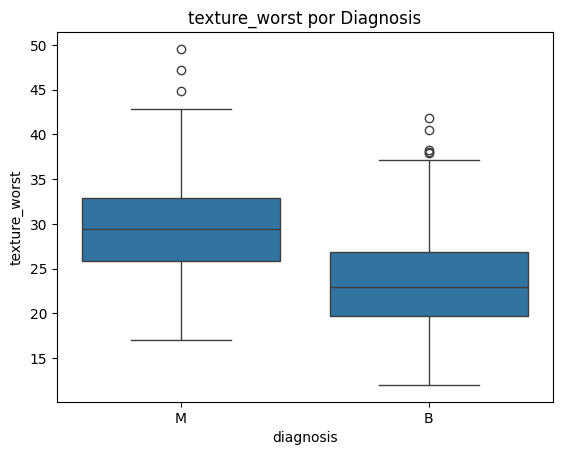

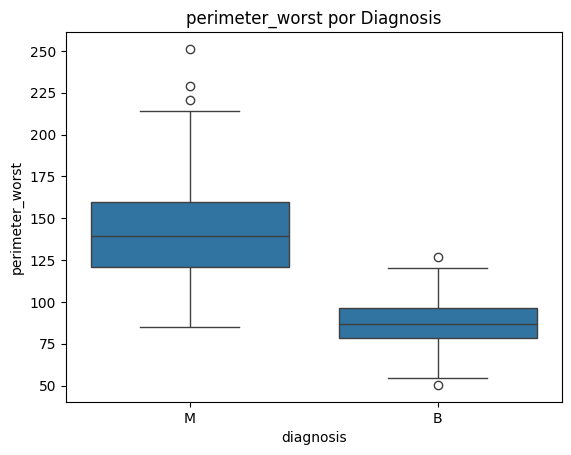

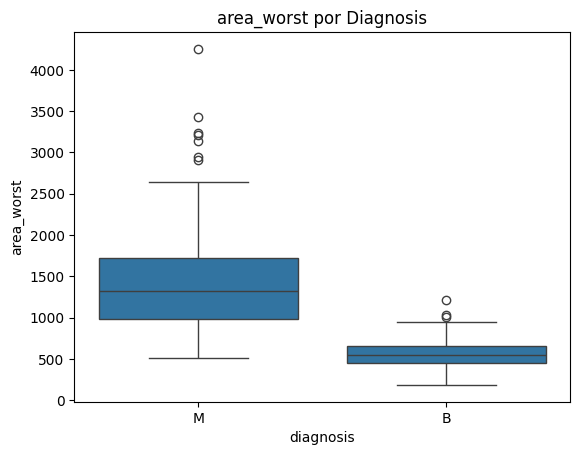

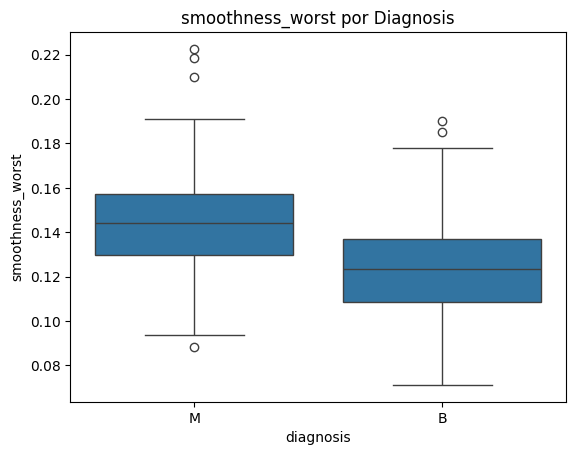

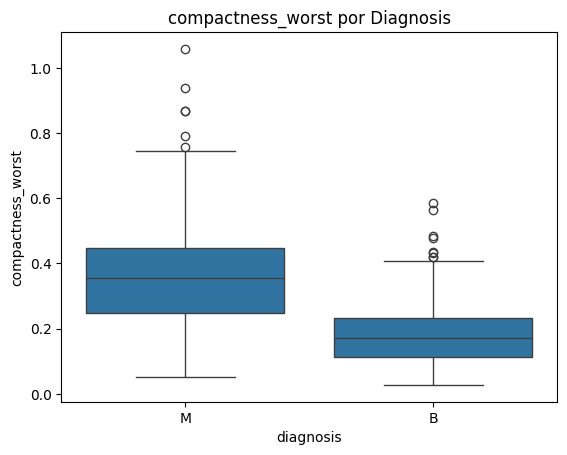

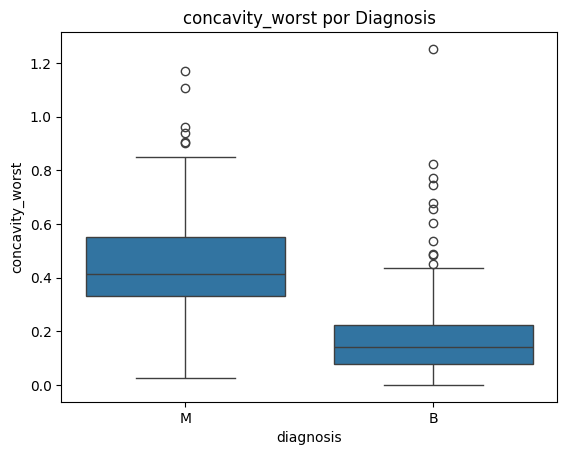

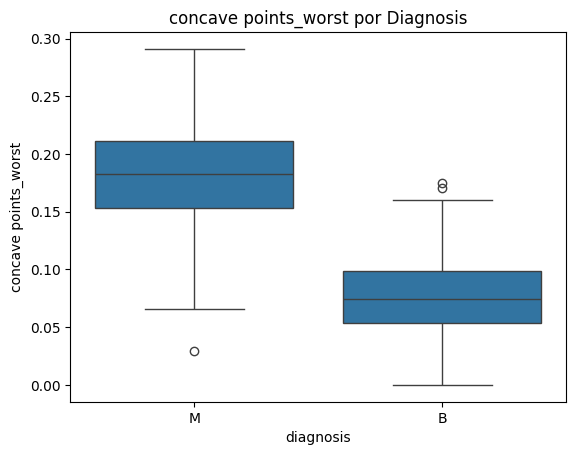

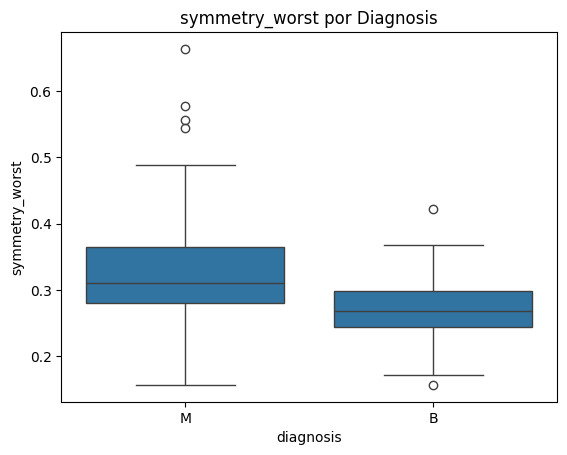

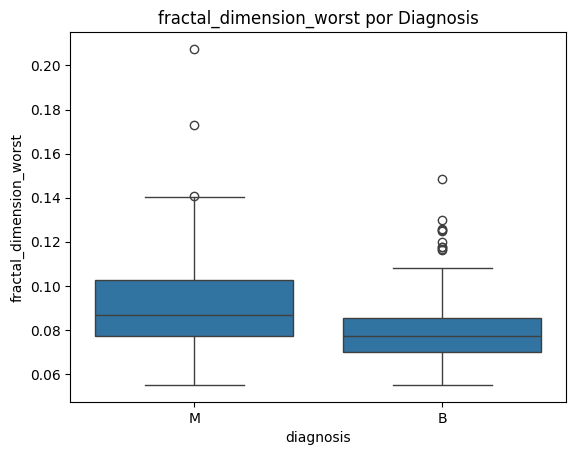

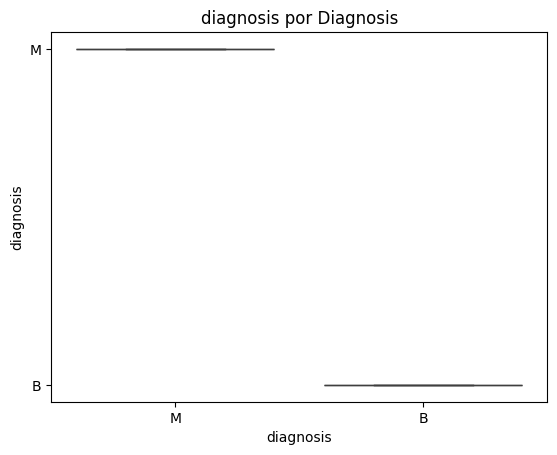

In [20]:
# Boxplot por categoría del target
for col in train_set:
    sns.boxplot(data=train_set, x=target, y=col)
    plt.title(f"{col} por Diagnosis")
    plt.show()

In [21]:
# para pder usar pointbiserialr el target binario tiene que ser numérico
train_set[target]=train_set[target].map({'M': 0, 'B': 1})

# Igual en test
test_set[target]=test_set[target].map({'M': 0, 'B': 1})

In [33]:
from scipy.stats import pointbiserialr

correlacion= []
for col in col_num_mean + col_num_se + col_num_worst:
    corr, pval = pointbiserialr(train_set[target], train_set[col])
    print(f"{col}: r={corr:.3f}, p={pval:.4f}")
    correlacion.append({'variable': col, 'r':np.abs(corr), 'p_valor': pval})

radius_mean: r=-0.728, p=0.0000
texture_mean: r=-0.414, p=0.0000
perimeter_mean: r=-0.740, p=0.0000
area_mean: r=-0.704, p=0.0000
smoothness_mean: r=-0.389, p=0.0000
compactness_mean: r=-0.606, p=0.0000
concavity_mean: r=-0.684, p=0.0000
concave points_mean: r=-0.776, p=0.0000
symmetry_mean: r=-0.341, p=0.0000
fractal_dimension_mean: r=-0.006, p=0.9063
radius_se: r=-0.559, p=0.0000
perimeter_se: r=-0.547, p=0.0000
area_se: r=-0.534, p=0.0000
compactness_se: r=-0.285, p=0.0000
concavity_se: r=-0.227, p=0.0000
concave points_se: r=-0.402, p=0.0000
symmetry_se: r=-0.006, p=0.8912
fractal_dimension_se: r=-0.070, p=0.1341
radius_worst: r=-0.778, p=0.0000
texture_worst: r=-0.467, p=0.0000
perimeter_worst: r=-0.783, p=0.0000
area_worst: r=-0.732, p=0.0000
smoothness_worst: r=-0.432, p=0.0000
compactness_worst: r=-0.587, p=0.0000
concavity_worst: r=-0.643, p=0.0000
concave points_worst: r=-0.786, p=0.0000
symmetry_worst: r=-0.426, p=0.0000
fractal_dimension_worst: r=-0.326, p=0.0000


In [34]:
df_correlacion = (pd.DataFrame(correlacion)).sort_values("r",ascending = False)

In [35]:
df_correlacion

,variable,r,p_valor
25,concave points_worst,0.786306,8.778594e-97
20,perimeter_worst,0.782881,2.093046e-95
18,radius_worst,0.777602,2.483688e-93
7,concave points_mean,0.775737,1.300875e-92
2,perimeter_mean,0.740027,4.687521e-80
21,area_worst,0.731761,1.932387e-77
0,radius_mean,0.728160,2.485053e-76
3,area_mean,0.703893,2.691158e-69
6,concavity_mean,0.683688,5.781926e-64
24,concavity_worst,0.643116,1.820808e-54


### Ejercicio 5

Observa correlaciones entre las features. Utiliza un gráfico apropiado para ello. ¿Crees que sea posible eliminar algunas features para mejorar el modelo? (No hace falta que lo hagas ahora, lo haremos si es necesario en un ejercicio posterior)

In [36]:
corr= train_set.drop(target,axis=1).corr()
print(corr)


                         radius_mean  texture_mean  perimeter_mean  area_mean  \
radius_mean                 1.000000      0.326358        0.997815   0.986740   
texture_mean                0.326358      1.000000        0.331800   0.318811   
perimeter_mean              0.997815      0.331800        1.000000   0.985960   
area_mean                   0.986740      0.318811        0.985960   1.000000   
smoothness_mean             0.188805     -0.011749        0.225840   0.200033   
compactness_mean            0.526901      0.246818        0.577536   0.518185   
concavity_mean              0.676323      0.292341        0.716044   0.685587   
concave points_mean         0.826984      0.289028        0.855414   0.827092   
symmetry_mean               0.148416      0.089454        0.185686   0.154040   
fractal_dimension_mean     -0.294777     -0.068576       -0.244184  -0.264658   
radius_se                   0.678727      0.261062        0.692054   0.731883   
perimeter_se                

<Axes: >

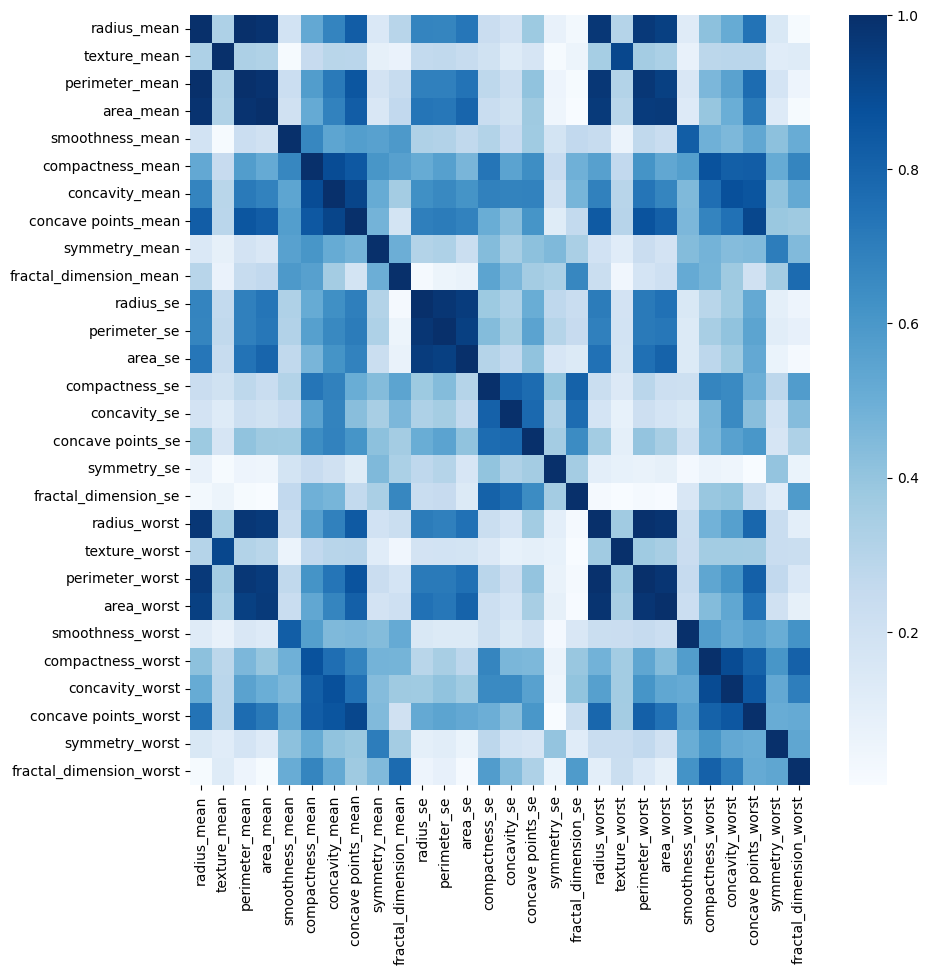

In [37]:
plt.figure(figsize=(10,10))
sns.heatmap(np.abs(corr), cmap= "Blues")

### Ejercicio 6:

Entrena (con validación cruzada) un modelo de RandomForestClassifier (con max_depth a 5) con todas las features (ojo incluso las que descartamos en el ejercicio 4) y guarda el perfomance ("balanced_accuracy") en test en una variable. Será nuestro base line de comparación

### Ejercicio 7

Vamos a emplear nuestras features del análisis visual pero descartando variables correladas entre sí (emplea la matriz ya obtenida en el ejercicio 5 o bien cualquier medio que creas conveniente). Descarta features y muestra la matriz de correlación para la selección final (recuerda, parte de la lista creada en el ejercicio 4)

### Ejercicio 8

Evalúa tu primer feature reduction. Entrena un modelo y evalúa su perfomance con los features que seleccionaste en el ejercicio anterios (emplea la validación cruzada)

### Ejercicio 9

Prueba ahora a hacer una feature selection utilizando ANOVA. Compara la validación cruzada con la del modelo baseline y con la del modelo anterior. (Pista: SelectKbest)

### Ejercicio 10

Prueba a hacer ahora una selección de features con RFE (Recursive Feature Elimination), hasta quedarte con 5 features. Evalúa perfomance en "balanced_accuracy" con cross_validation y compara con la baseline.

### Ejercicio 11

Prueba a eliminar features con el modelo de RandomForestClassifier (emplea SelectFromModel de sklearn). Utiliza esta vez una regresión logística para entrenar con las features escogidas y compara con el baseline. Muestra primero la importancia obtenida con el modelo baseline (que básicamente es el mismo que vamos a usar con SelectFromModel). Prueba primero para features por encima de la mediana y luego para las 5 primeras.

### Ejercicio EXTRA:

Investiga RFECV y obten el número optimo de features siguiendo esta técnica pero con el "balanced_accuracy" como métrica.